# GroupWork 2 - Part 1: Empirical Mode Decomposition (EMD)

Participants:

Simen Fritzner

Petter Kvam Haugan

## Signal Generation (from GroupWork1)

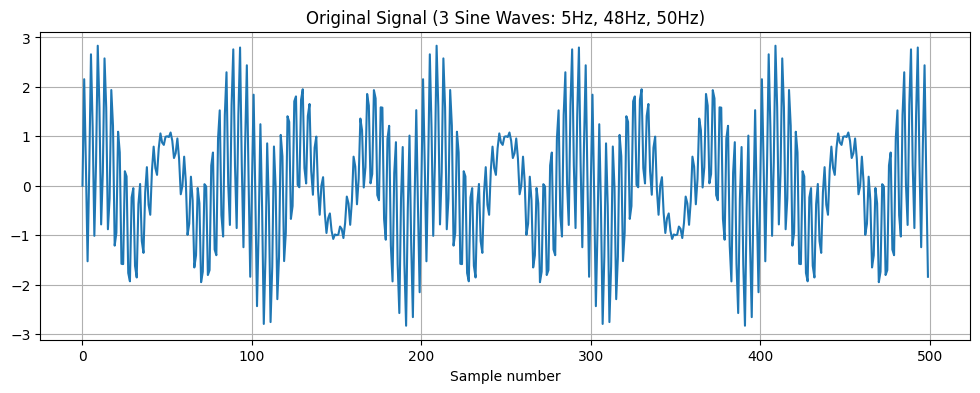

In [70]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import CubicSpline, PchipInterpolator
from scipy.signal import hilbert
from scipy.fft import fft, fftfreq

def generateMultiSinWave(freqs, N=512, sr=1024):
    """Generate a sum of multiple sine waves."""
    time_vector = np.arange(N) / sr
    combined_signal = np.zeros(N)  # Real signal
    
    for freq in freqs:
        combined_signal += np.sin(2 * np.pi * freq * time_vector)
    
    return combined_signal

def add_white_noise(signal, noise_level=0.2):
    """Add white Gaussian noise to signal"""
    noise = np.random.normal(0, noise_level, len(signal))
    return signal + noise

def plotSignal(signal, title='Real part of signal'):
    plt.figure(figsize=(12, 4))
    plt.plot(np.real(signal))
    plt.title(title)
    plt.xlabel('Sample number')
    plt.grid()
    plt.show()

# Generate base signal
freqs = [5, 48, 50]
sr = 200
N = 500

signal = generateMultiSinWave(freqs, N, sr)
time_vector = np.arange(N) / sr

plotSignal(signal, 'Original Signal (3 Sine Waves: 5Hz, 48Hz, 50Hz)')

## EMD Implementation - Step by Step

Empirical Mode Decomposition (EMD) is a data-driven method for decomposing non-linear and non-stationary signals into Intrinsic Mode Functions (IMFs).

Key steps in EMD:
1. **Extrema Detection**: Find all local maxima and minima in the signal
2. **Envelope Creation**: Interpolate through maxima (upper envelope) and minima (lower envelope) using spline interpolation
3. **Mean Envelope**: Calculate the mean of upper and lower envelopes
4. **Sifting**: Subtract the mean envelope from the signal to get a candidate IMF
5. **IMF Criterion Check**: Verify if the candidate satisfies IMF conditions (equal extrema/zero-crossings, symmetric envelopes)
6. **Residual**: After extracting an IMF, subtract it from the signal and repeat until residual is monotonic

The process continues until the residual becomes monotonic (no more oscillations).

In [71]:
def find_extrema(signal):
    """Find local maxima and minima in the signal."""
    maxima_idx = []
    minima_idx = []
    
    for i in range(1, len(signal) - 1):
        if signal[i] > signal[i-1] and signal[i] > signal[i+1]:
            maxima_idx.append(i)
        elif signal[i] < signal[i-1] and signal[i] < signal[i+1]:
            minima_idx.append(i)
    
    return np.array(maxima_idx), np.array(minima_idx)

def create_envelope(signal, extrema_idx, kind='cubic'):
    """
    Create envelope by interpolating through extrema points.
    kind: 'cubic' for natural cubic spline, 'pchip' for Hermite interpolation
    """
    if len(extrema_idx) < 2:
        return None
    
    x = extrema_idx
    y = signal[extrema_idx]
    x_new = np.arange(len(signal))
    
    if kind == 'cubic':
        # Natural cubic spline
        interpolator = CubicSpline(x, y, bc_type='natural')
    elif kind == 'pchip':
        # PCHIP (Hermite) interpolation
        interpolator = PchipInterpolator(x, y)
    else:
        raise ValueError("kind must be 'cubic' or 'pchip'")
    
    return interpolator(x_new)

def visualize_sifting_step(signal, time_vector, maxima_idx, minima_idx, 
                          upper_env, lower_env, mean_env, imf_num, sift_num):
    """Visualize a single sifting step with extrema and envelopes."""
    plt.figure(figsize=(14, 6))
    
    # Plot signal
    plt.plot(time_vector, signal, 'b-', label='Signal', linewidth=1.5)
    
    # Plot extrema
    if len(maxima_idx) > 0:
        plt.plot(time_vector[maxima_idx], signal[maxima_idx], 'ro', 
                label='Maxima', markersize=6)
    if len(minima_idx) > 0:
        plt.plot(time_vector[minima_idx], signal[minima_idx], 'go', 
                label='Minima', markersize=6)
    
    # Plot envelopes
    if upper_env is not None:
        plt.plot(time_vector, upper_env, 'r--', label='Upper Envelope', linewidth=1)
    if lower_env is not None:
        plt.plot(time_vector, lower_env, 'g--', label='Lower Envelope', linewidth=1)
    if mean_env is not None:
        plt.plot(time_vector, mean_env, 'k--', label='Mean Envelope', linewidth=2)
    
    plt.title(f'IMF {imf_num} - Sifting Step {sift_num}')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def sift_process(signal, time_vector, max_sifts=10, spline_type='cubic', 
                use_default_stopping=False, visualize_steps=False, imf_num=1):
    """
    Perform sifting process to extract one IMF.
    
    Parameters:
    - signal: input signal
    - time_vector: time axis
    - max_sifts: maximum number of sifting iterations (used if use_default_stopping=False)
    - spline_type: 'cubic' or 'pchip'
    - use_default_stopping: if True, use SD criterion; if False, use fixed iterations
    - visualize_steps: if True, show visualization for each sift
    - imf_num: IMF number for labeling
    """
    h = signal.copy()
    
    for sift_iter in range(max_sifts if not use_default_stopping else 100):
        # Find extrema
        maxima_idx, minima_idx = find_extrema(h)
        
        # Check if we have enough extrema
        if len(maxima_idx) < 2 or len(minima_idx) < 2:
            break
        
        # Create envelopes
        upper_env = create_envelope(h, maxima_idx, kind=spline_type)
        lower_env = create_envelope(h, minima_idx, kind=spline_type)
        
        if upper_env is None or lower_env is None:
            break
        
        # Calculate mean envelope
        mean_env = (upper_env + lower_env) / 2
        
        # Visualize if requested (only first sift for first IMF)
        if visualize_steps and sift_iter == 0:
            visualize_sifting_step(h, time_vector, maxima_idx, minima_idx,
                                  upper_env, lower_env, mean_env, imf_num, sift_iter + 1)
        
        # Subtract mean envelope
        h_prev = h.copy()
        h = h - mean_env
        
        # Check stopping criterion
        if use_default_stopping:
            # Calculate SD between successive sifts
            sd = np.sum((h_prev - h)**2) / (np.sum(h_prev**2) + 1e-10)
            if sd < 0.3:  # SD threshold
                break
        else:
            # Fixed number of iterations
            if sift_iter >= max_sifts - 1:
                break
    
    return h

def is_monotonic(signal):
    """Check if signal is monotonic (residual condition)."""
    maxima_idx, minima_idx = find_extrema(signal)
    # Monotonic if total extrema <= 2
    return len(maxima_idx) + len(minima_idx) <= 2

def emd(signal, time_vector, max_imfs=10, max_sifts=10, spline_type='cubic',
       use_default_stopping=False, visualize_first_imf=False, mask_amp = 1.0, mask_freq = 100):
    """
    Perform complete EMD on signal.
    
    Parameters:
    - signal: input signal
    - time_vector: time axis
    - max_imfs: maximum number of IMFs to extract
    - max_sifts: maximum sifting iterations per IMF (if not using default stopping)
    - spline_type: 'cubic' for natural cubic spline, 'pchip' for Hermite
    - use_default_stopping: if True, use SD criterion; if False, use fixed sifts
    - visualize_first_imf: if True, visualize first sifting step of first IMF
    
    Returns:
    - imfs: list of IMFs
    - residue: final residual
    """
    imfs = []
    residue = signal.copy()
    
    for imf_idx in range(max_imfs):
        # Check if residue is monotonic
        if is_monotonic(residue):
            break
        # Extract IMF
        visualize = visualize_first_imf and imf_idx == 0

        if imf_idx == 0:
            imf = separate_mode_mix(signal, time_vector, mask_amp, mask_freq, 
                      max_sifts=max_sifts, spline_type=spline_type, 
                      use_default_stopping=use_default_stopping, visualize=False)
        else:
            imf = sift_process(residue, time_vector, max_sifts=max_sifts,
                            spline_type=spline_type, 
                            use_default_stopping=use_default_stopping,
                            visualize_steps=visualize, imf_num=imf_idx + 1)
        
        imfs.append(imf)
        residue = residue - imf
        
        # Safety check
        if np.all(imf == 0):
            break
    
    return imfs, residue

import numpy as np

def separate_mode_mix(signal, time_vector, mask_amp, mask_freq, 
                      max_sifts=10, spline_type='cubic', 
                      use_default_stopping=False, visualize=False):
    """
    Attempts to separate mixed modes using a pair of anti-phase sinusoidal masks.
    
    This is a simplified version of Masking EMD. A more robust solution is a full 
    Ensemble EMD (EEMD) with white noise.
    
    Parameters:
    - signal: The input signal (or residue) to be sifted.
    - time_vector: The time axis.
    - mask_amp: The amplitude of the masking sine wave.
    - mask_freq: The frequency of the masking sine wave.
    - max_sifts: Maximum sifting iterations.
    - spline_type: Type of spline for envelope ('cubic' or 'pchip').
    - use_default_stopping: Whether to use SD stopping criterion.
    - visualize: If True, plots the first sifting step.
    
    Returns:
    - The extracted Intrinsic Mode Function (IMF).
    """
    
    # Create the primary masking sinusoid
    mask = mask_amp * np.sin(2 * np.pi * mask_freq * time_vector)
    
    # Add and subtract the mask to create a complementary pair of signals
    signal_plus = signal + mask
    signal_minus = signal - mask
    
    # Sift both of the masked signals
    # We pass 'imf_num=1' for visualization labeling purposes only
    imf_plus = sift_process(signal_plus, time_vector, max_sifts=max_sifts,
                            spline_type=spline_type, 
                            use_default_stopping=use_default_stopping,
                            visualize_steps=visualize, imf_num=1)
    
    imf_minus = sift_process(signal_minus, time_vector, max_sifts=max_sifts,
                             spline_type=spline_type, 
                             use_default_stopping=use_default_stopping,
                             visualize_steps=False, imf_num=1) # Avoid duplicate plots
    
    imf_plus_demasked = imf_plus - mask
    imf_minus_demasked = imf_minus + mask  # Equivalent to imf_minus + mask
    
    final_imf = (imf_plus_demasked + imf_minus_demasked) / 2
    
    return final_imf


def plot_imfs(imfs, residue, time_vector, title_prefix="EMD Decomposition"):
    """Plot all IMFs and residue."""
    n_plots = len(imfs) + 1
    fig, axes = plt.subplots(n_plots, 1, figsize=(14, 2*n_plots))
    
    if n_plots == 1:
        axes = [axes]
    
    for i, imf in enumerate(imfs):
        axes[i].plot(time_vector, imf, 'b-', linewidth=1)
        axes[i].set_ylabel(f'IMF {i+1}')
        axes[i].grid(True, alpha=0.3)
        axes[i].set_xlim([time_vector[0], time_vector[-1]])
    
    axes[-1].plot(time_vector, residue, 'r-', linewidth=1)
    axes[-1].set_ylabel('Residue')
    axes[-1].set_xlabel('Time (s)')
    axes[-1].grid(True, alpha=0.3)
    axes[-1].set_xlim([time_vector[0], time_vector[-1]])
    
    plt.suptitle(title_prefix, fontsize=14, y=0.995)
    plt.tight_layout()
    plt.show()
    
    return len(imfs)

### FFT

In [72]:
def compute_fft(signal, sr):
    """Compute FFT of a signal."""
    N = len(signal)
    yf = fft(signal)
    xf = fftfreq(N, 1/sr)[:N//2]
    return xf, 2.0/N * np.abs(yf[:N//2])

def plot_imf_ffts(imfs, sr, title_prefix="FFT of IMFs"):
    """Plot FFT for all IMFs."""
    n_imfs = len(imfs)
    fig, axes = plt.subplots(n_imfs, 1, figsize=(12, 2*n_imfs))
    
    if n_imfs == 1:
        axes = [axes]
    
    for i, imf in enumerate(imfs):
        xf, yf = compute_fft(imf, sr)
        axes[i].plot(xf, yf, 'b-', linewidth=1)
        axes[i].set_ylabel(f'IMF {i+1}')
        axes[i].set_xlim([0, 100])
        axes[i].grid(True, alpha=0.3)
    
    axes[-1].set_xlabel('Frequency (Hz)')
    plt.suptitle(title_prefix, fontsize=14, y=0.995)
    plt.tight_layout()
    plt.show()

### Hilbert

In [73]:
def compute_instantaneous_frequency(signal, sr):
    """Compute instantaneous frequency using Hilbert transform."""
    analytic_signal = hilbert(signal)
    instantaneous_phase = np.unwrap(np.angle(analytic_signal))
    instantaneous_frequency = np.diff(instantaneous_phase) * sr / (2 * np.pi)
    return instantaneous_frequency

def plot_instantaneous_frequencies(imfs, time_vector, sr, title_prefix="Instantaneous Frequency"):
    """Plot instantaneous frequency for all IMFs."""
    n_imfs = len(imfs)
    fig, axes = plt.subplots(n_imfs, 1, figsize=(12, 2*n_imfs))
    
    if n_imfs == 1:
        axes = [axes]
    
    for i, imf in enumerate(imfs):
        inst_freq = compute_instantaneous_frequency(imf, sr)
        axes[i].plot(time_vector[:-1], inst_freq, 'b-', linewidth=0.5)
        axes[i].set_ylabel(f'IMF {i+1} (Hz)')
        axes[i].set_ylim([0, 100])
        axes[i].grid(True, alpha=0.3)
    
    axes[-1].set_xlabel('Time (s)')
    plt.suptitle(title_prefix, fontsize=14, y=0.995)
    plt.tight_layout()
    plt.show()

In [74]:
def emd_simple(signal, time_vector, max_imfs=10, max_sifts=10, spline_type='cubic',
               use_default_stopping=False):
    """
    Simplified EMD without masking (for use in EEMD).
    
    Parameters:
    - signal: input signal
    - time_vector: time axis
    - max_imfs: maximum number of IMFs to extract
    - max_sifts: maximum sifting iterations per IMF
    - spline_type: 'cubic' or 'pchip'
    - use_default_stopping: if True, use SD criterion
    
    Returns:
    - imfs: list of IMFs
    - residue: final residual
    """
    imfs = []
    residue = signal.copy()
    
    for imf_idx in range(max_imfs):
        # Check if residue is monotonic
        if is_monotonic(residue):
            break
        
        # Extract IMF (no masking)
        imf = sift_process(residue, time_vector, max_sifts=max_sifts,
                          spline_type=spline_type, 
                          use_default_stopping=use_default_stopping,
                          visualize_steps=False, imf_num=imf_idx + 1)
        
        imfs.append(imf)
        residue = residue - imf
        
        # Safety check
        if np.all(imf == 0):
            break
    
    return imfs, residue


def eemd(signal, time_vector, n_ensembles=100, noise_std=0.2, 
         max_imfs=10, max_sifts=10, spline_type='cubic',
         use_default_stopping=False, random_seed=None, verbose=True):
    """
    Ensemble Empirical Mode Decomposition (EEMD).
    
    Performs EMD on multiple noise-added realizations and averages the results
    to reduce mode mixing and improve decomposition quality.
    
    Parameters:
    - signal: input signal
    - time_vector: time axis
    - n_ensembles: number of ensemble members (typically 100-200)
    - noise_std: standard deviation of added white noise (relative to signal std)
    - max_imfs: maximum number of IMFs to extract per ensemble
    - max_sifts: maximum sifting iterations per IMF
    - spline_type: 'cubic' for natural cubic spline, 'pchip' for Hermite
    - use_default_stopping: if True, use SD criterion; if False, use fixed sifts
    - random_seed: random seed for reproducibility
    - verbose: if True, show progress
    
    Returns:
    - imfs: list of averaged IMFs
    - residue: averaged final residual
    """
    if random_seed is not None:
        np.random.seed(random_seed)
    
    # Calculate noise amplitude based on signal standard deviation
    signal_std = np.std(signal)
    noise_amplitude = noise_std * signal_std
    
    if verbose:
        print(f"Running EEMD with {n_ensembles} ensembles...")
        print(f"Noise amplitude: {noise_amplitude:.6f} (std ratio: {noise_std})")
    
    # Storage for all ensemble IMFs
    all_ensemble_imfs = []
    all_ensemble_residues = []
    
    # Run EMD on each noise-added realization
    for ensemble_idx in range(n_ensembles):
        if verbose and (ensemble_idx + 1) % 20 == 0:
            print(f"  Processing ensemble {ensemble_idx + 1}/{n_ensembles}...")
        
        # Add white Gaussian noise
        noise = np.random.normal(0, noise_amplitude, len(signal))
        noisy_signal = signal + noise
        
        # Perform EMD on noisy signal
        imfs, residue = emd_simple(noisy_signal, time_vector, 
                                   max_imfs=max_imfs,
                                   max_sifts=max_sifts,
                                   spline_type=spline_type,
                                   use_default_stopping=use_default_stopping)
        
        all_ensemble_imfs.append(imfs)
        all_ensemble_residues.append(residue)
    
    # Find the maximum number of IMFs across all ensembles
    max_n_imfs = max(len(imfs) for imfs in all_ensemble_imfs)
    
    if verbose:
        print(f"Maximum IMFs extracted: {max_n_imfs}")
        print("Averaging across ensembles...")
    
    # Average IMFs across ensembles
    averaged_imfs = []
    for imf_idx in range(max_n_imfs):
        # Collect this IMF from all ensembles that have it
        imf_ensemble = []
        for ensemble_imfs in all_ensemble_imfs:
            if imf_idx < len(ensemble_imfs):
                imf_ensemble.append(ensemble_imfs[imf_idx])
        
        # Average across ensembles
        averaged_imf = np.mean(imf_ensemble, axis=0)
        averaged_imfs.append(averaged_imf)
    
    # Average residues
    averaged_residue = np.mean(all_ensemble_residues, axis=0)
    
    if verbose:
        print(f"EEMD complete! Extracted {len(averaged_imfs)} averaged IMFs")
    
    return averaged_imfs, averaged_residue


def plot_eemd_comparison(signal, time_vector, sr, 
                         imfs_emd, residue_emd, 
                         imfs_eemd, residue_eemd,
                         emd_label="EMD", eemd_label="EEMD"):
    """
    Plot side-by-side comparison of EMD vs EEMD results with FFT.
    
    Parameters:
    - signal: original signal
    - time_vector: time axis
    - sr: sampling rate
    - imfs_emd: IMFs from standard EMD
    - residue_emd: residue from standard EMD
    - imfs_eemd: IMFs from EEMD
    - residue_eemd: residue from EEMD
    - emd_label: label for EMD method
    - eemd_label: label for EEMD method
    """
    n_imfs = max(len(imfs_emd), len(imfs_eemd))
    
    # Create figure with subplots (IMFs in time domain + FFT)
    fig = plt.figure(figsize=(16, 2.5 * (n_imfs + 2)))
    
    # Plot original signal
    ax = plt.subplot(n_imfs + 2, 2, 1)
    ax.plot(time_vector, signal, 'k-', linewidth=1)
    ax.set_ylabel('Original')
    ax.set_title(f'Original Signal (Time Domain)')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([time_vector[0], time_vector[-1]])
    
    ax = plt.subplot(n_imfs + 2, 2, 2)
    xf, yf = compute_fft(signal, sr)
    ax.plot(xf, yf, 'k-', linewidth=1)
    ax.set_ylabel('Original')
    ax.set_title(f'Original Signal (FFT)')
    ax.set_xlim([0, 100])
    ax.grid(True, alpha=0.3)
    
    # Plot IMFs
    for i in range(n_imfs):
        # Time domain - EMD
        ax = plt.subplot(n_imfs + 2, 2, 2*(i+1) + 1)
        if i < len(imfs_emd):
            ax.plot(time_vector, imfs_emd[i], 'b-', linewidth=0.8, label=emd_label)
        if i < len(imfs_eemd):
            ax.plot(time_vector, imfs_eemd[i], 'r-', linewidth=0.8, alpha=0.7, label=eemd_label)
        ax.set_ylabel(f'IMF {i+1}')
        ax.grid(True, alpha=0.3)
        ax.set_xlim([time_vector[0], time_vector[-1]])
        if i == 0:
            ax.legend(loc='upper right')
        
        # FFT - EMD vs EEMD
        ax = plt.subplot(n_imfs + 2, 2, 2*(i+1) + 2)
        if i < len(imfs_emd):
            xf, yf = compute_fft(imfs_emd[i], sr)
            ax.plot(xf, yf, 'b-', linewidth=0.8, label=emd_label)
        if i < len(imfs_eemd):
            xf, yf = compute_fft(imfs_eemd[i], sr)
            ax.plot(xf, yf, 'r-', linewidth=0.8, alpha=0.7, label=eemd_label)
        ax.set_xlim([0, 100])
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.legend(loc='upper right')
    
    # Plot residues
    ax = plt.subplot(n_imfs + 2, 2, 2*(n_imfs+1) + 1)
    ax.plot(time_vector, residue_emd, 'b-', linewidth=0.8, label=emd_label)
    ax.plot(time_vector, residue_eemd, 'r-', linewidth=0.8, alpha=0.7, label=eemd_label)
    ax.set_ylabel('Residue')
    ax.set_xlabel('Time (s)')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([time_vector[0], time_vector[-1]])
    ax.legend(loc='upper right')
    
    ax = plt.subplot(n_imfs + 2, 2, 2*(n_imfs+1) + 2)
    xf, yf = compute_fft(residue_emd, sr)
    ax.plot(xf, yf, 'b-', linewidth=0.8, label=emd_label)
    xf, yf = compute_fft(residue_eemd, sr)
    ax.plot(xf, yf, 'r-', linewidth=0.8, alpha=0.7, label=eemd_label)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_xlim([0, 100])
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')
    
    plt.suptitle(f'{emd_label} vs {eemd_label} Comparison', fontsize=14, y=0.995)
    plt.tight_layout()
    plt.show()

## Ensemble Empirical Mode Decomposition (EEMD)

EEMD addresses the mode mixing problem in EMD by using an ensemble approach:

**Algorithm:**
1. Add white noise to the original signal
2. Perform EMD on the noisy signal
3. Repeat steps 1-2 for N ensemble members (typically 100-200)
4. Average the corresponding IMFs across all ensemble members
5. The added noise cancels out through averaging, leaving cleaner IMFs

**Advantages over standard EMD:**
- **Solves mode mixing**: Noise-assisted decomposition separates close frequencies better
- **No parameter tuning**: Unlike masking EMD, no need to specify mask frequency/amplitude
- **Robust**: More stable decomposition, especially for noisy signals
- **Standard method**: Widely used in literature for real-world signals

## 1. EMD with Natural Cubic Spline - Fixed 10 Sifts

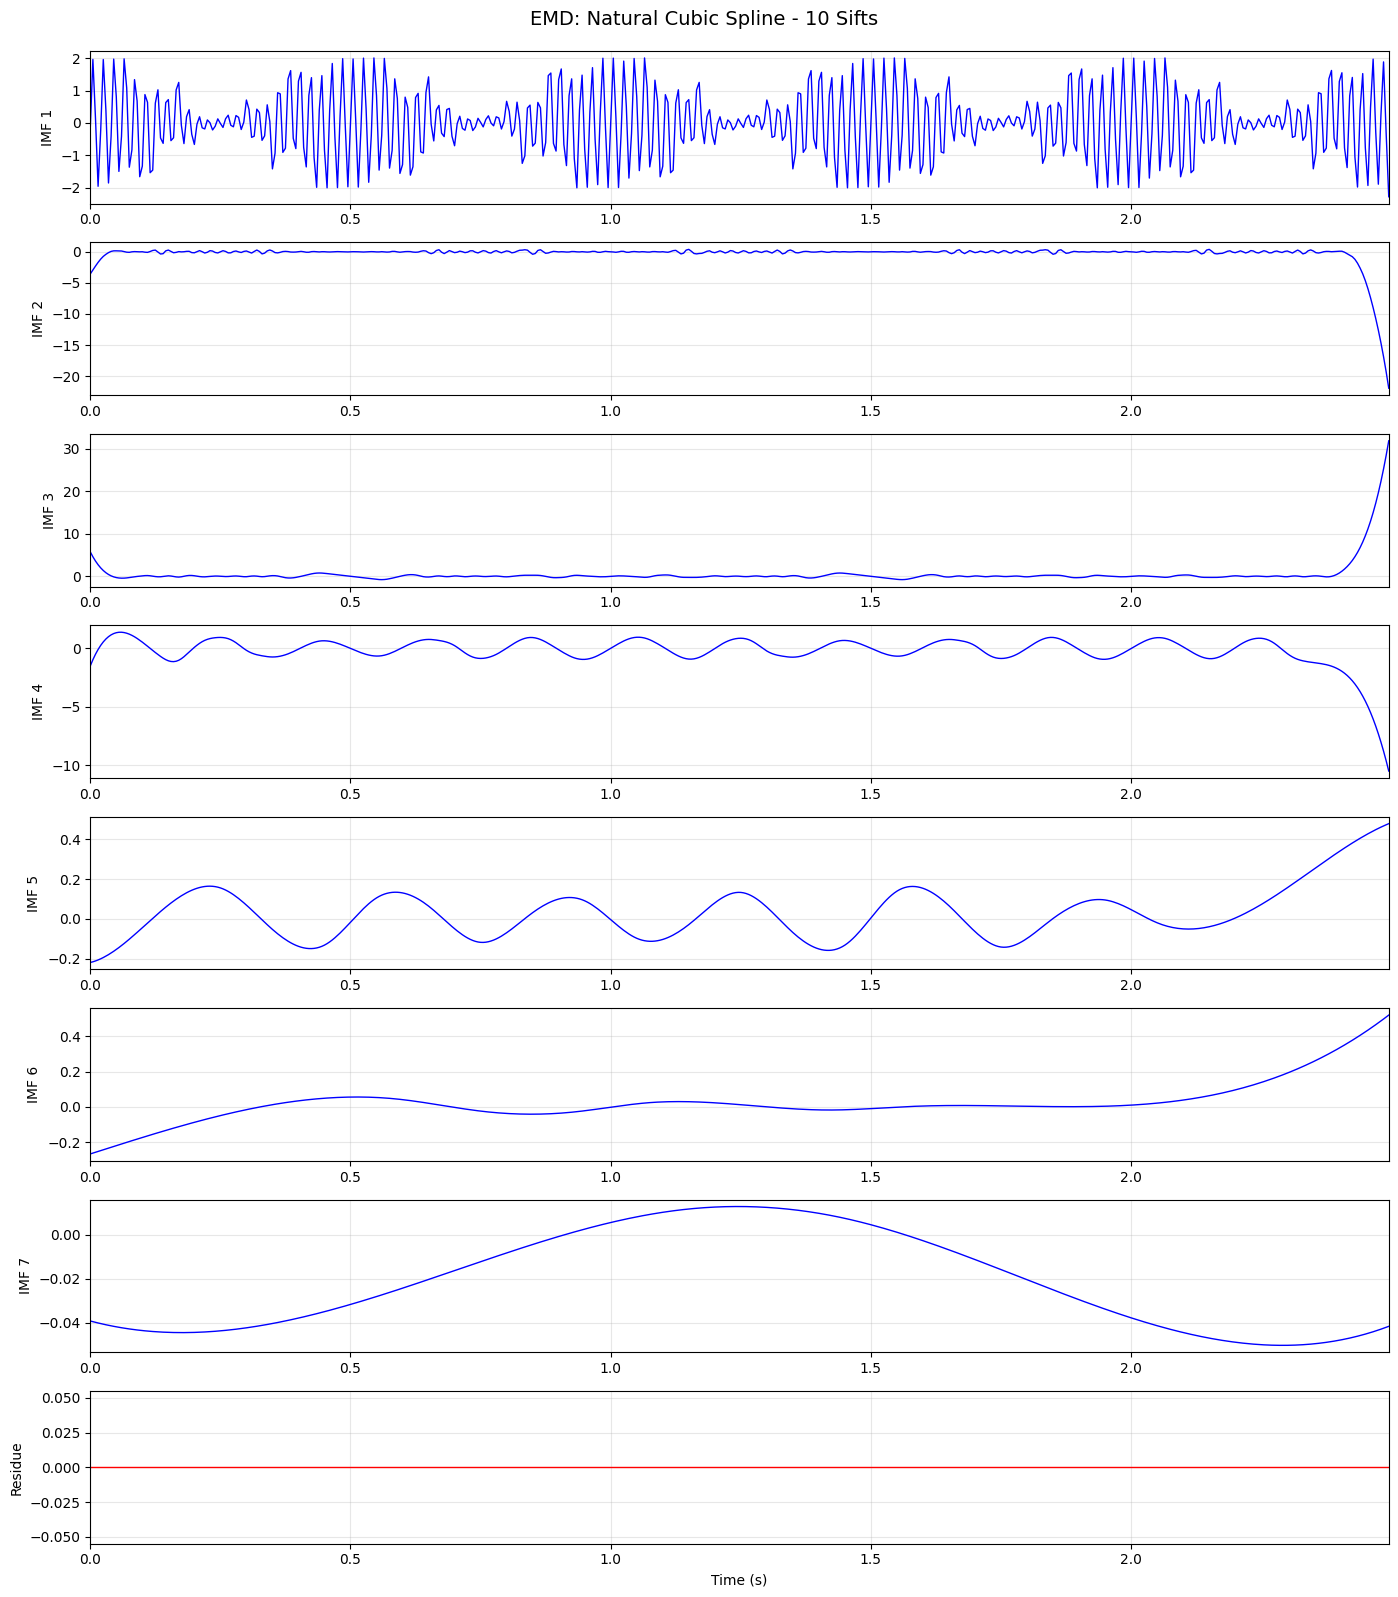

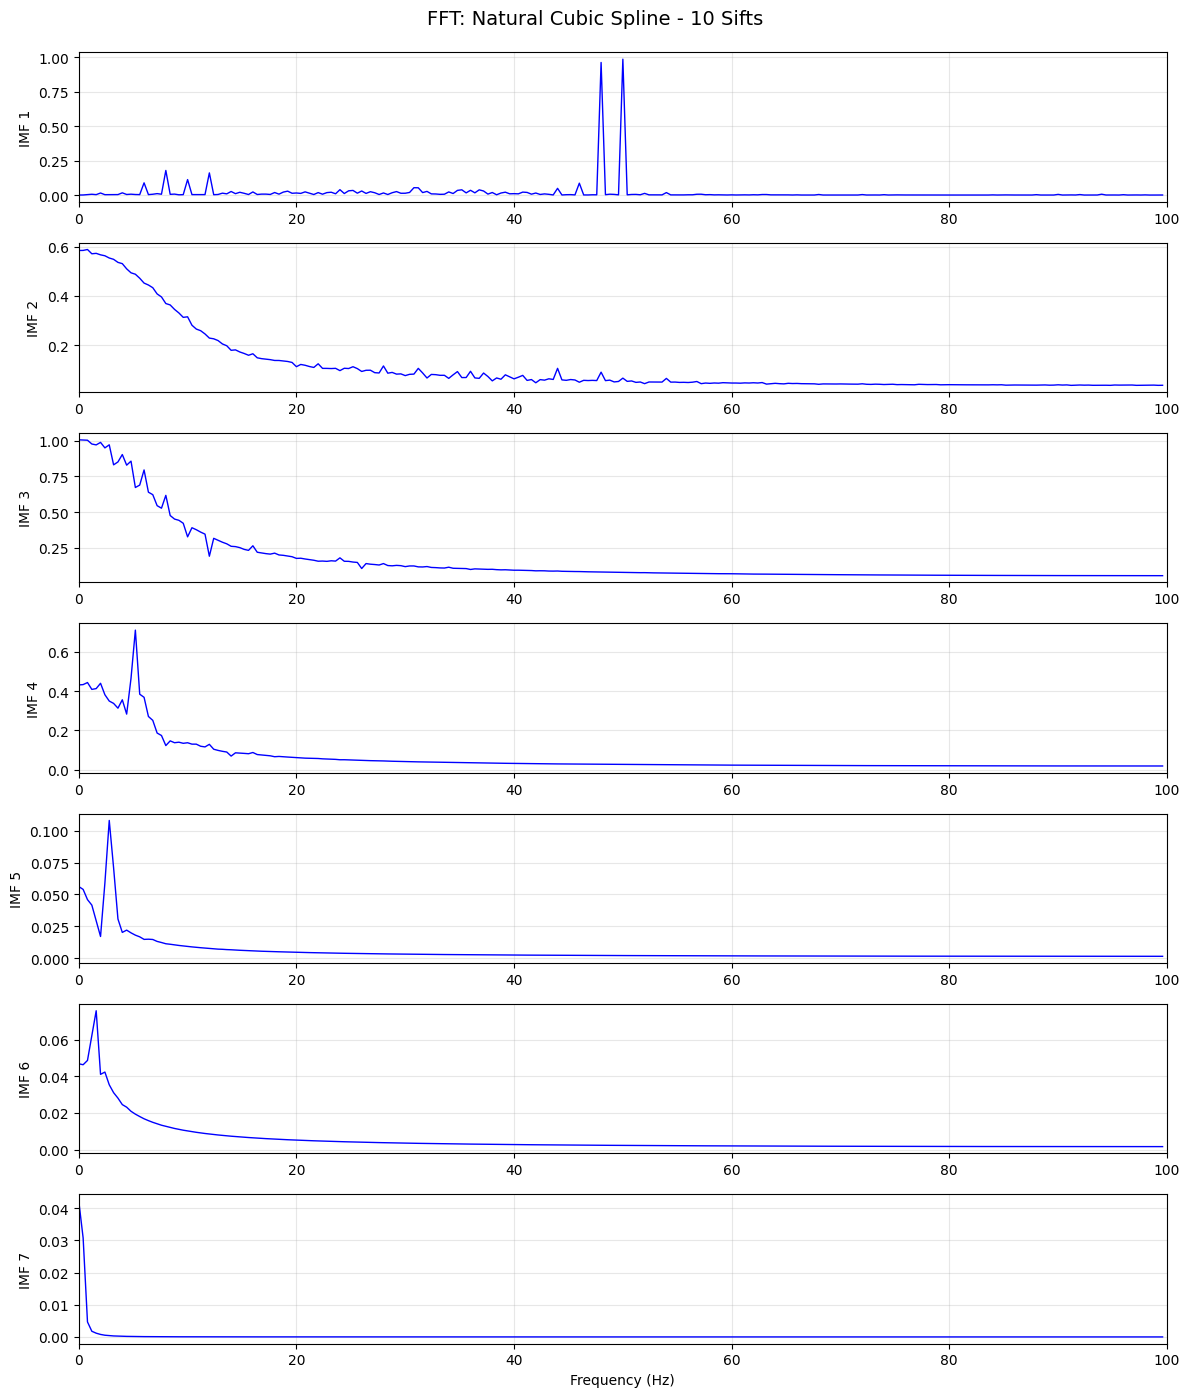

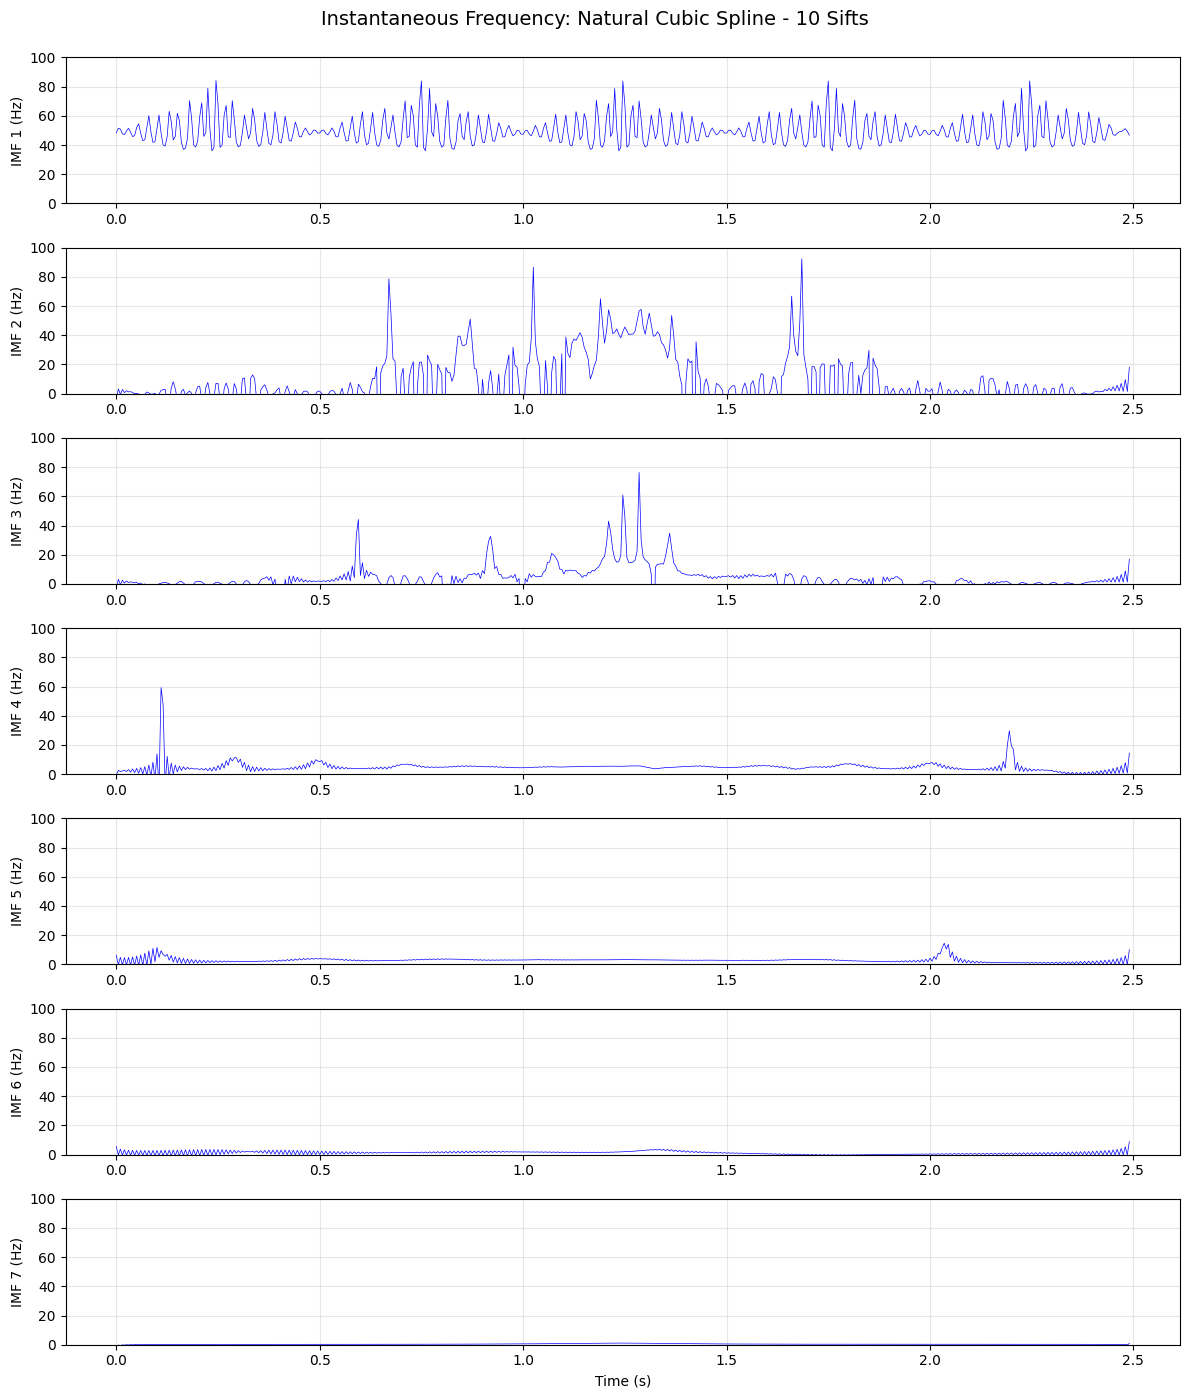

In [75]:
# EMD with Natural Cubic Spline, 10 sifts
imfs_cubic_10, residue_cubic_10 = emd(signal, time_vector, max_sifts=10, 
                                       spline_type='cubic', 
                                       use_default_stopping=False,
                                       visualize_first_imf=True, mask_amp=1.0, mask_freq=70)

n_imfs = plot_imfs(imfs_cubic_10, residue_cubic_10, time_vector, 
                   "EMD: Natural Cubic Spline - 10 Sifts")

plot_imf_ffts(imfs_cubic_10, sr, "FFT: Natural Cubic Spline - 10 Sifts")
plot_instantaneous_frequencies(imfs_cubic_10, time_vector, sr, 
                               "Instantaneous Frequency: Natural Cubic Spline - 10 Sifts")


## 2. EMD with Natural Cubic Spline - Default Stopping Criterion

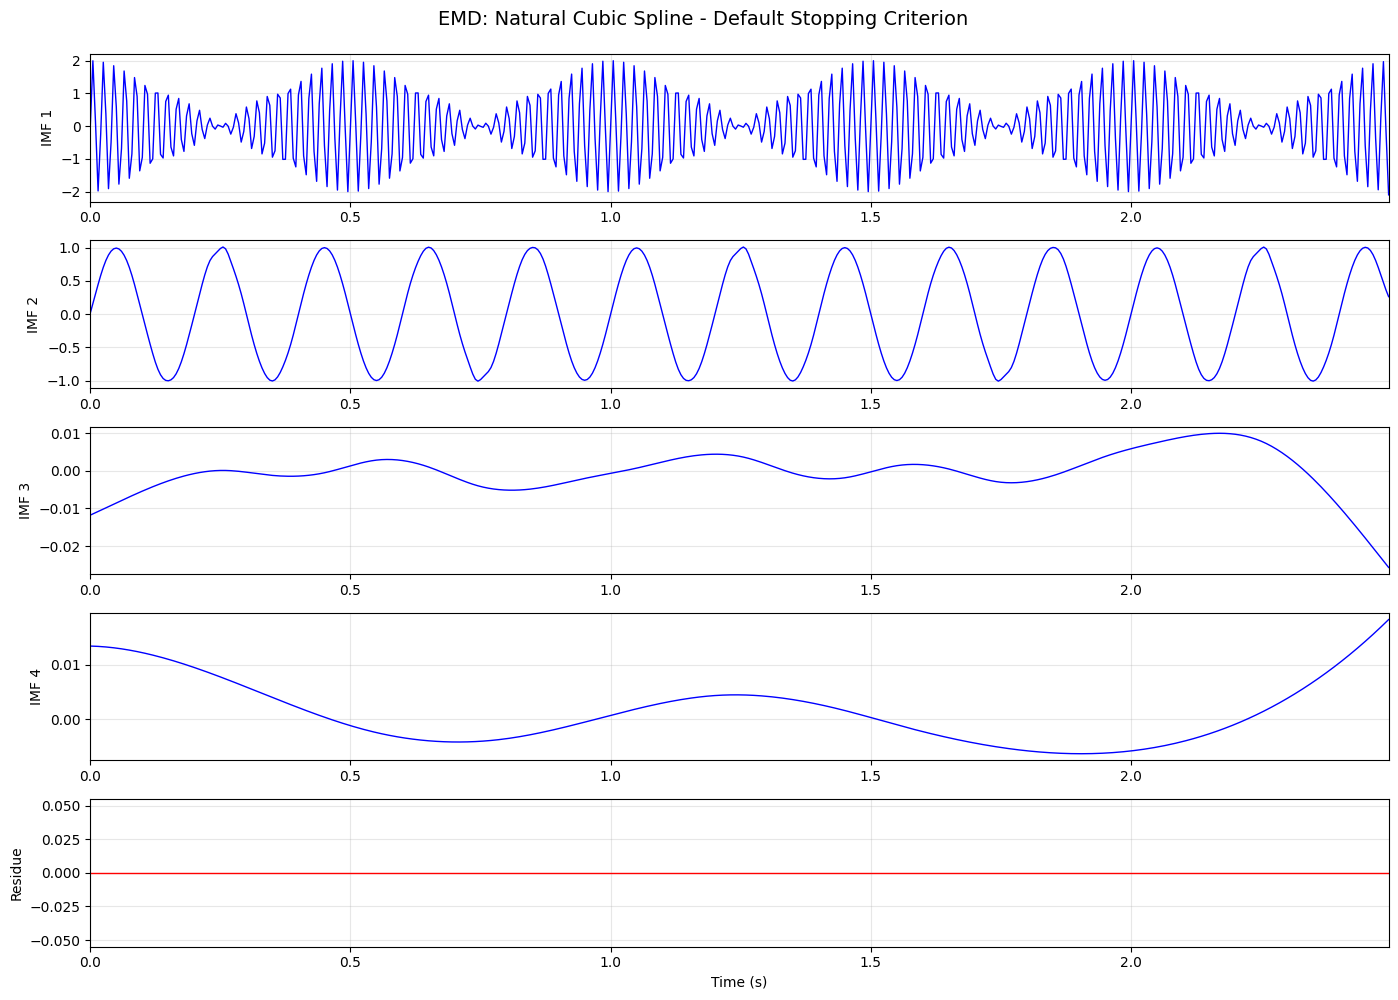

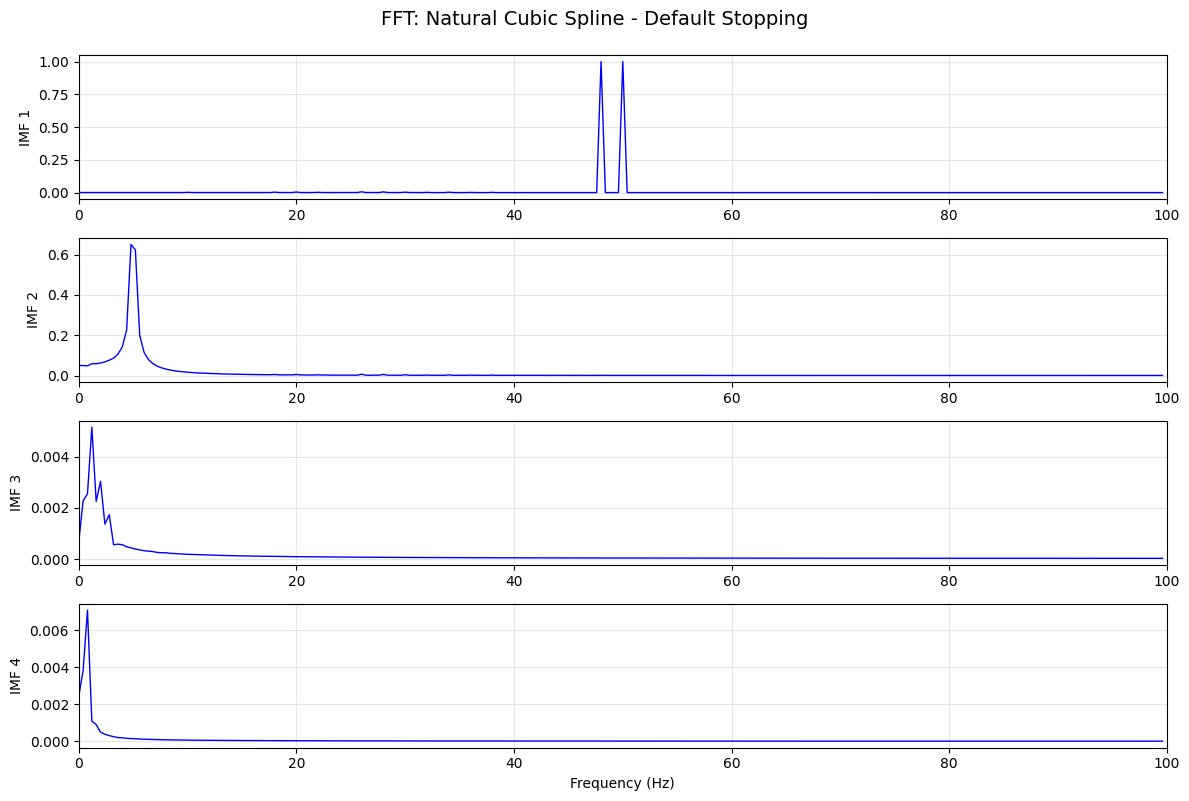

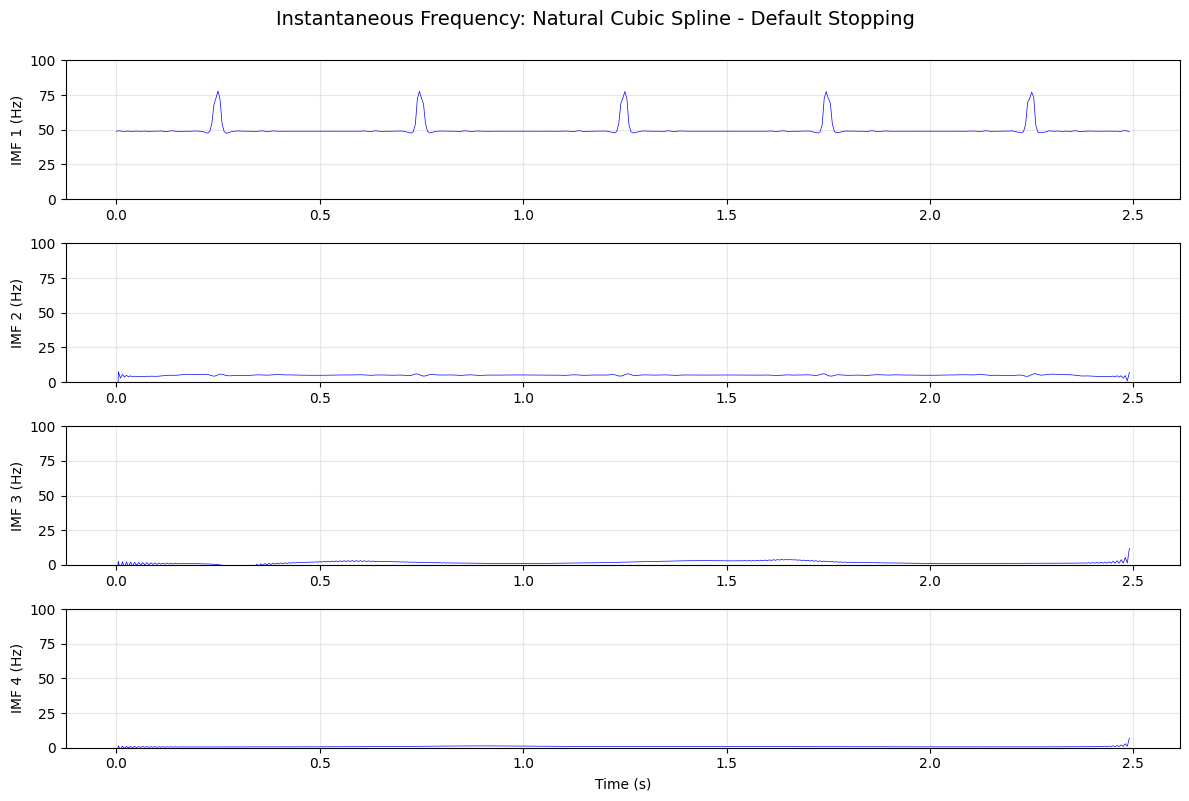

In [76]:
# EMD with Natural Cubic Spline, default stopping (SD < 0.3)
imfs_cubic_default, residue_cubic_default = emd(signal, time_vector, 
                                                 spline_type='cubic',
                                                 use_default_stopping=True)

n_imfs = plot_imfs(imfs_cubic_default, residue_cubic_default, time_vector,
                   "EMD: Natural Cubic Spline - Default Stopping Criterion")

plot_imf_ffts(imfs_cubic_default, sr, "FFT: Natural Cubic Spline - Default Stopping")
plot_instantaneous_frequencies(imfs_cubic_default, time_vector, sr,
                               "Instantaneous Frequency: Natural Cubic Spline - Default Stopping")



## 3. EMD with Hermite (PCHIP) Spline - Fixed 10 Sifts

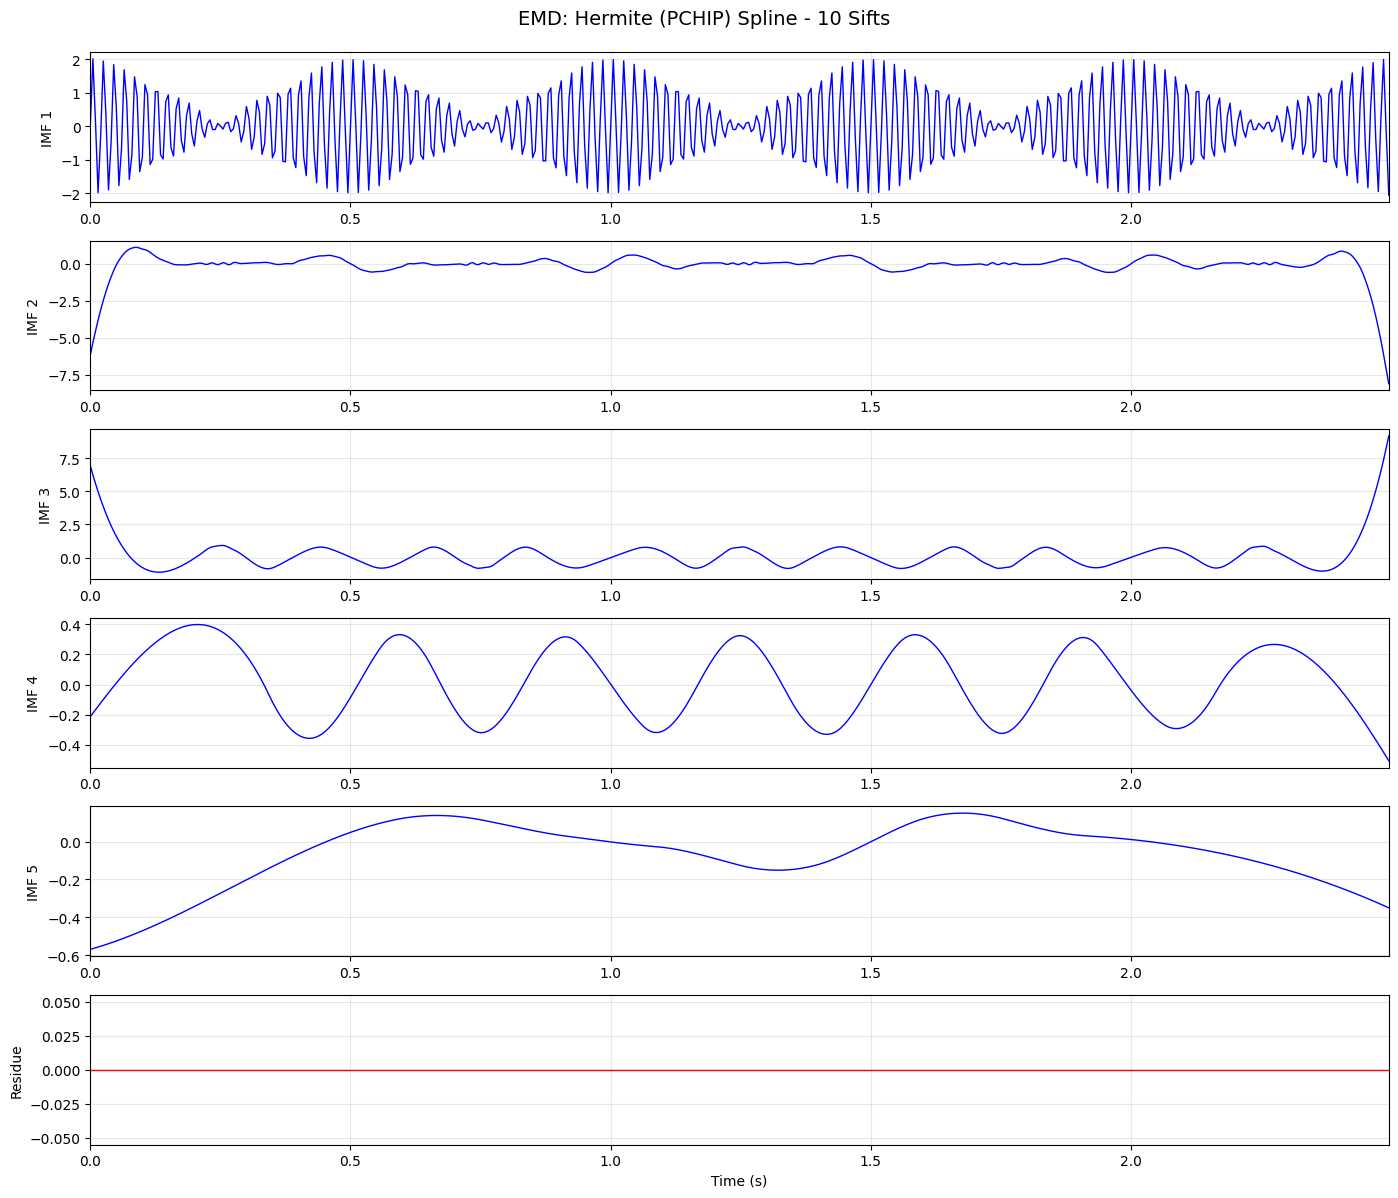

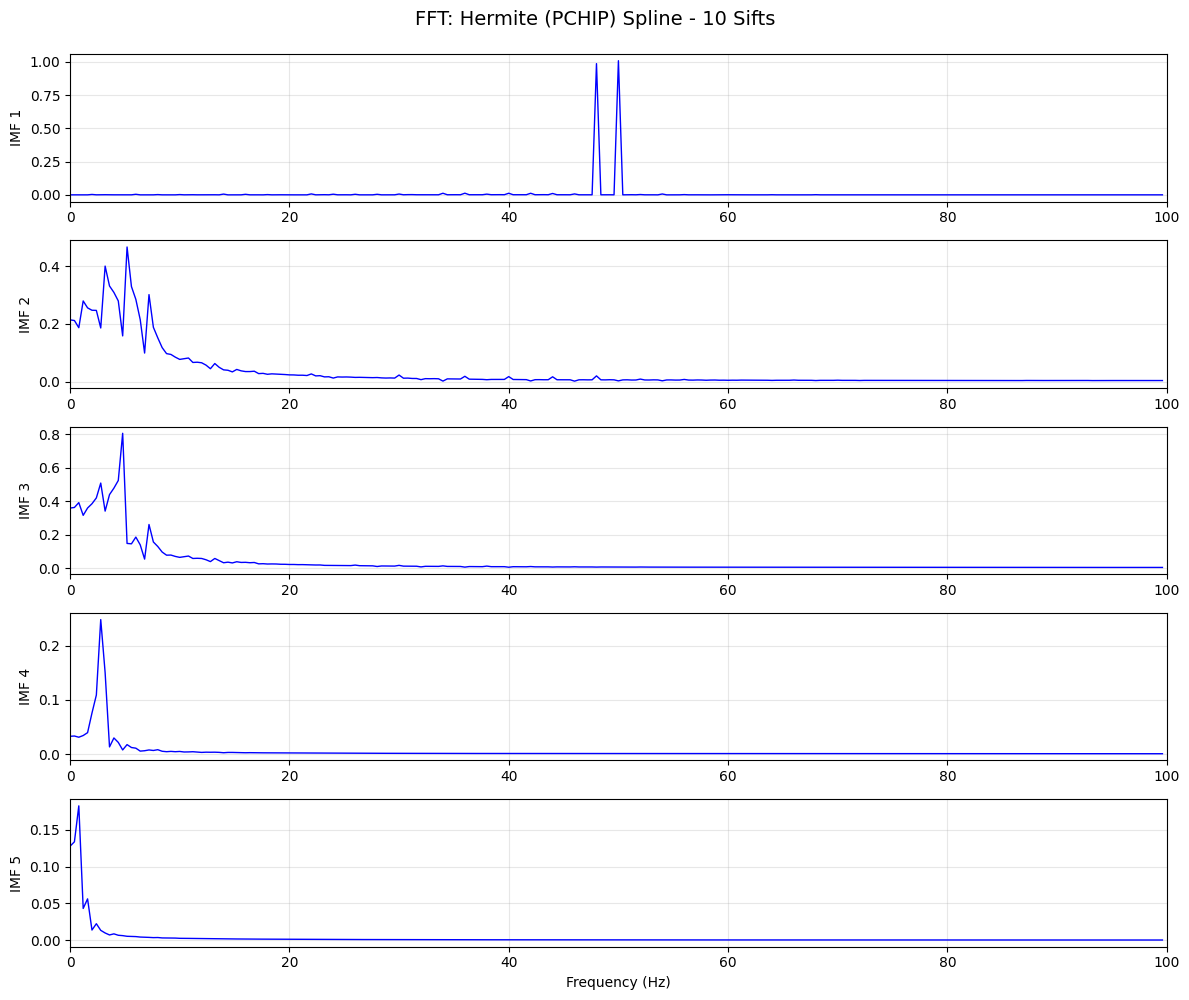

In [77]:
# EMD with Hermite (PCHIP) Spline, 10 sifts
imfs_pchip_10, residue_pchip_10 = emd(signal, time_vector, max_sifts=10,
                                       spline_type='pchip',
                                       use_default_stopping=False)

n_imfs = plot_imfs(imfs_pchip_10, residue_pchip_10, time_vector,
                   "EMD: Hermite (PCHIP) Spline - 10 Sifts")
plot_imf_ffts(imfs_pchip_10, sr, "FFT: Hermite (PCHIP) Spline - 10 Sifts")

## 4. EMD with Hermite (PCHIP) Spline - Default Stopping Criterion

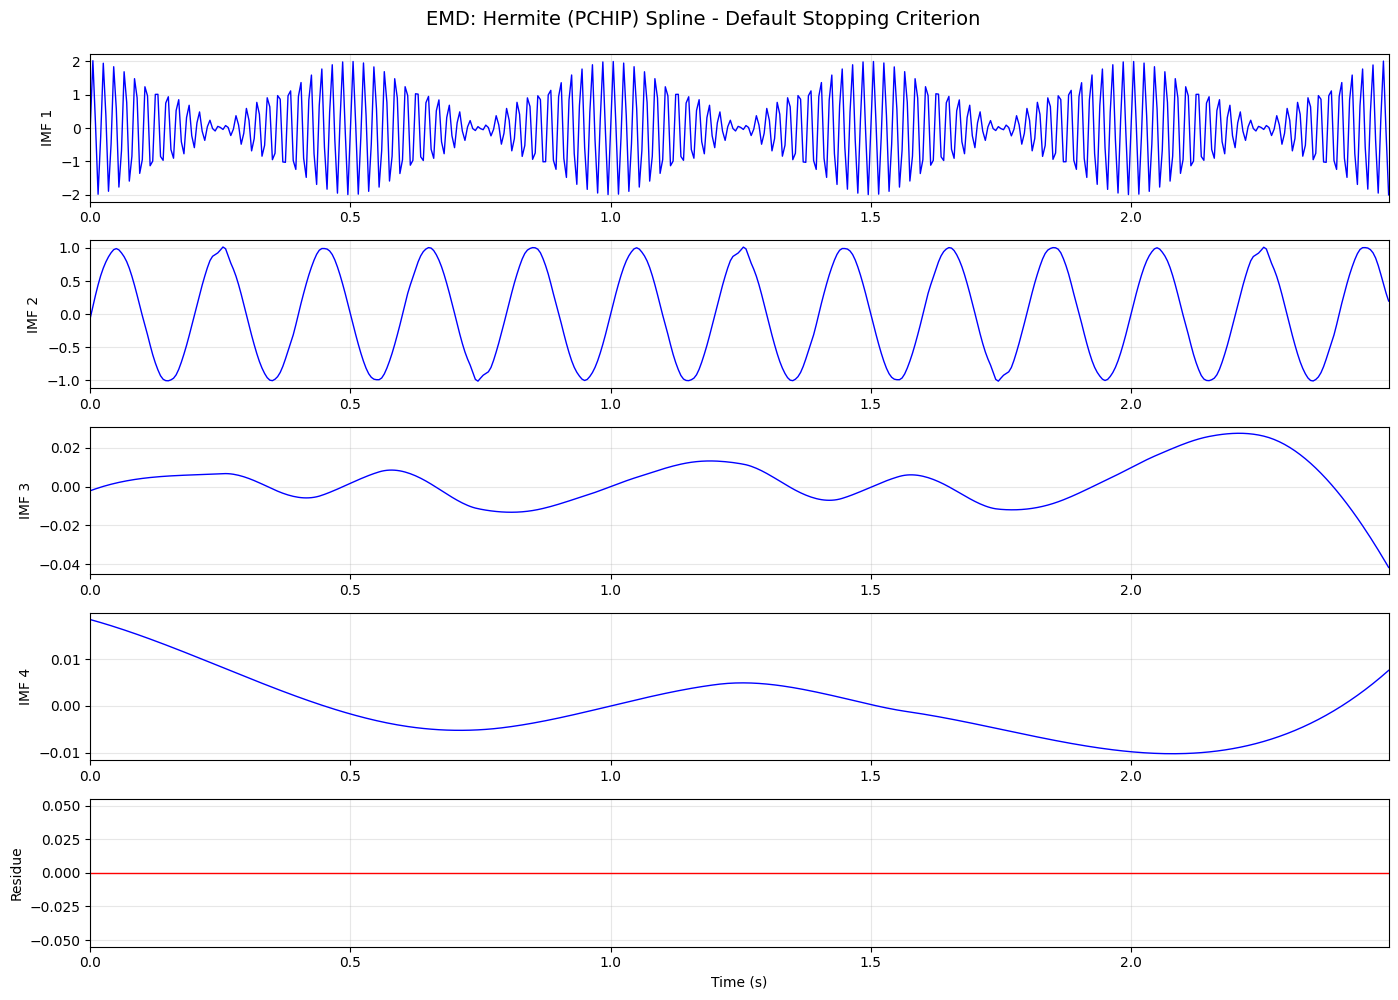

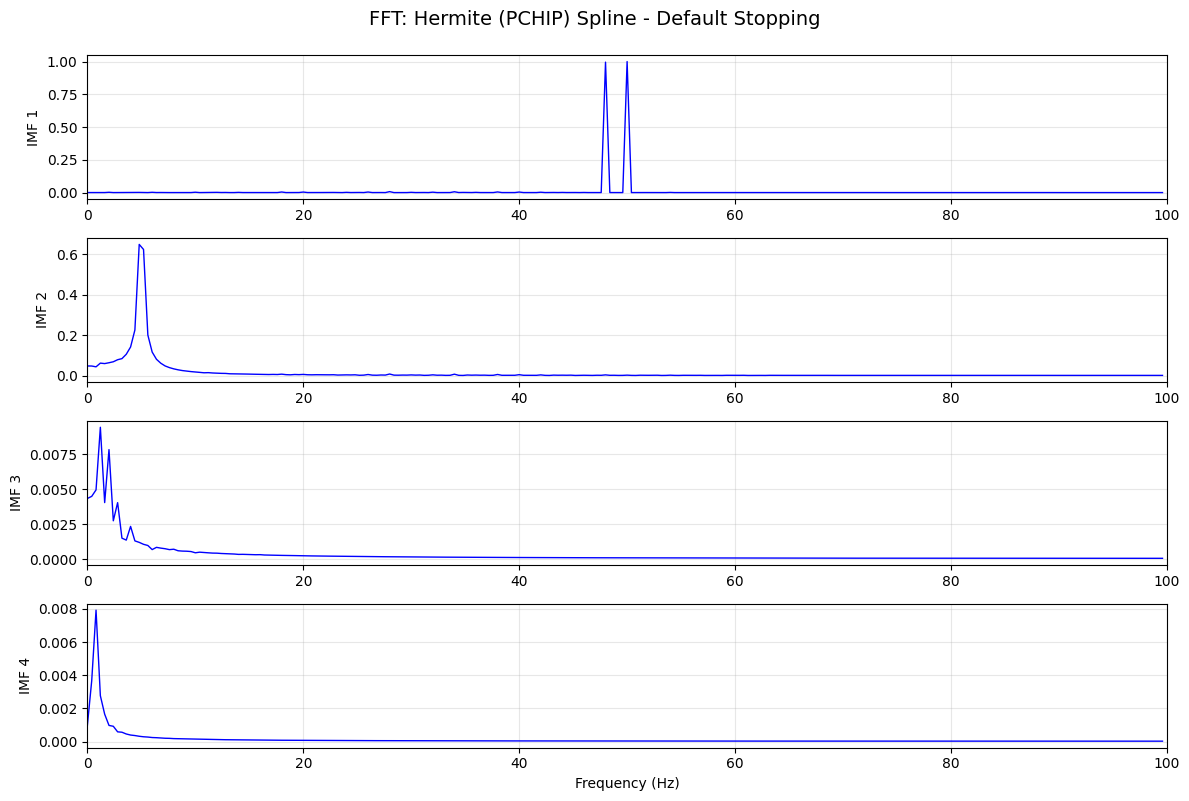

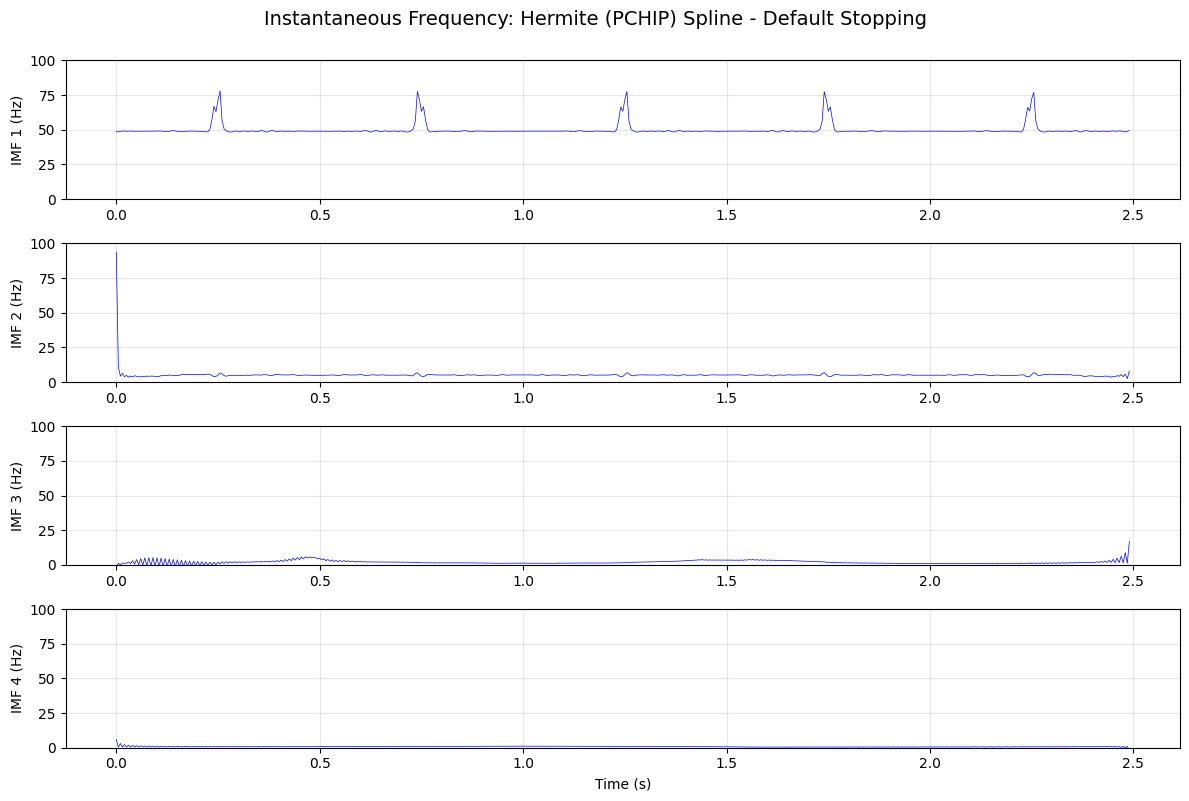

In [78]:
# EMD with Hermite (PCHIP) Spline, default stopping (SD < 0.3)
imfs_pchip_default, residue_pchip_default = emd(signal, time_vector,
                                                 spline_type='pchip',
                                                 use_default_stopping=True)

n_imfs = plot_imfs(imfs_pchip_default, residue_pchip_default, time_vector,
                   "EMD: Hermite (PCHIP) Spline - Default Stopping Criterion")
plot_imf_ffts(imfs_pchip_default, sr, "FFT: Hermite (PCHIP) Spline - Default Stopping")
plot_instantaneous_frequencies(imfs_pchip_default, time_vector, sr,
                               "Instantaneous Frequency: Hermite (PCHIP) Spline - Default Stopping")

## Analysis with Added Noise and Offset

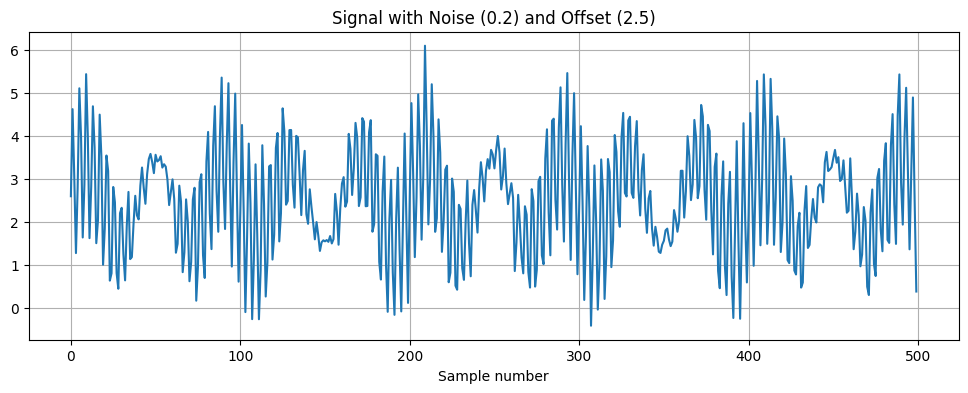

In [79]:
# Generate signal with noise and offset
np.random.seed(42)  # For reproducibility
signal_noisy = add_white_noise(signal, noise_level=0.2)
signal_noisy_offset = signal_noisy + 2.5

plotSignal(signal_noisy_offset, 'Signal with Noise (0.2) and Offset (2.5)')

### 1. Natural Cubic Spline - 10 Sifts (with Noise and Offset)

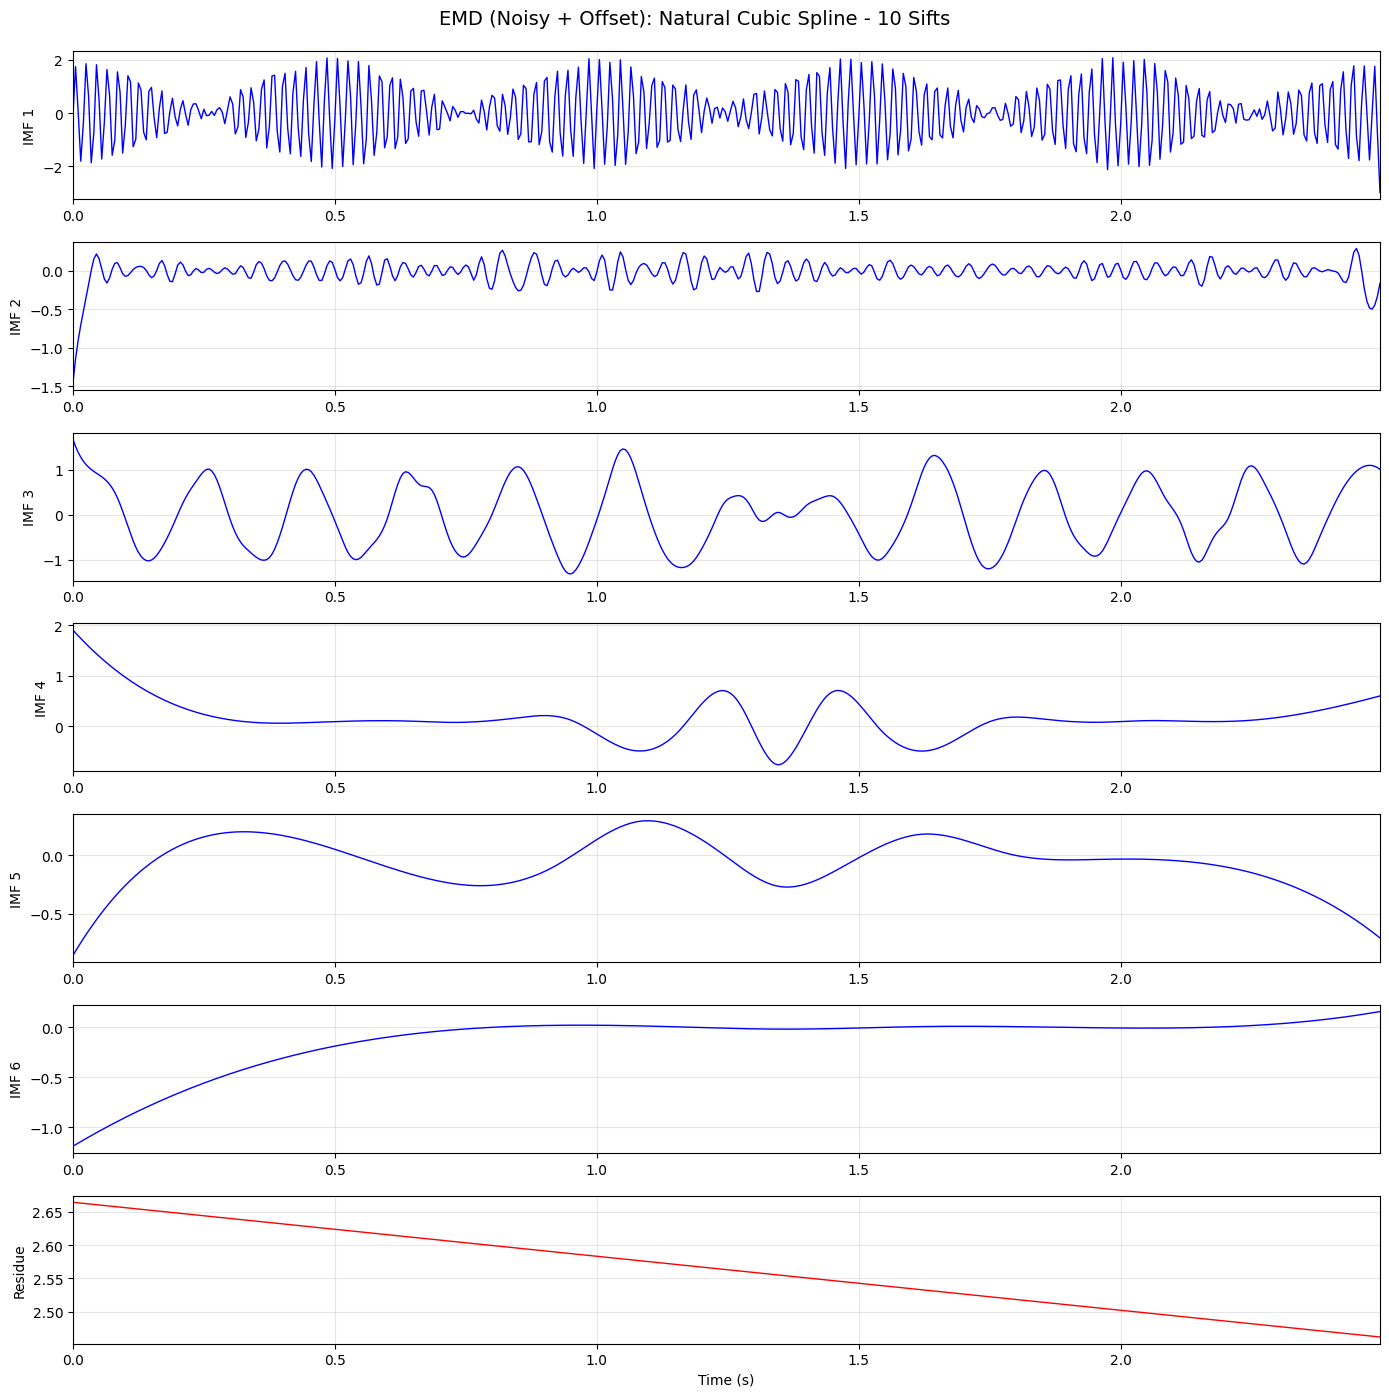

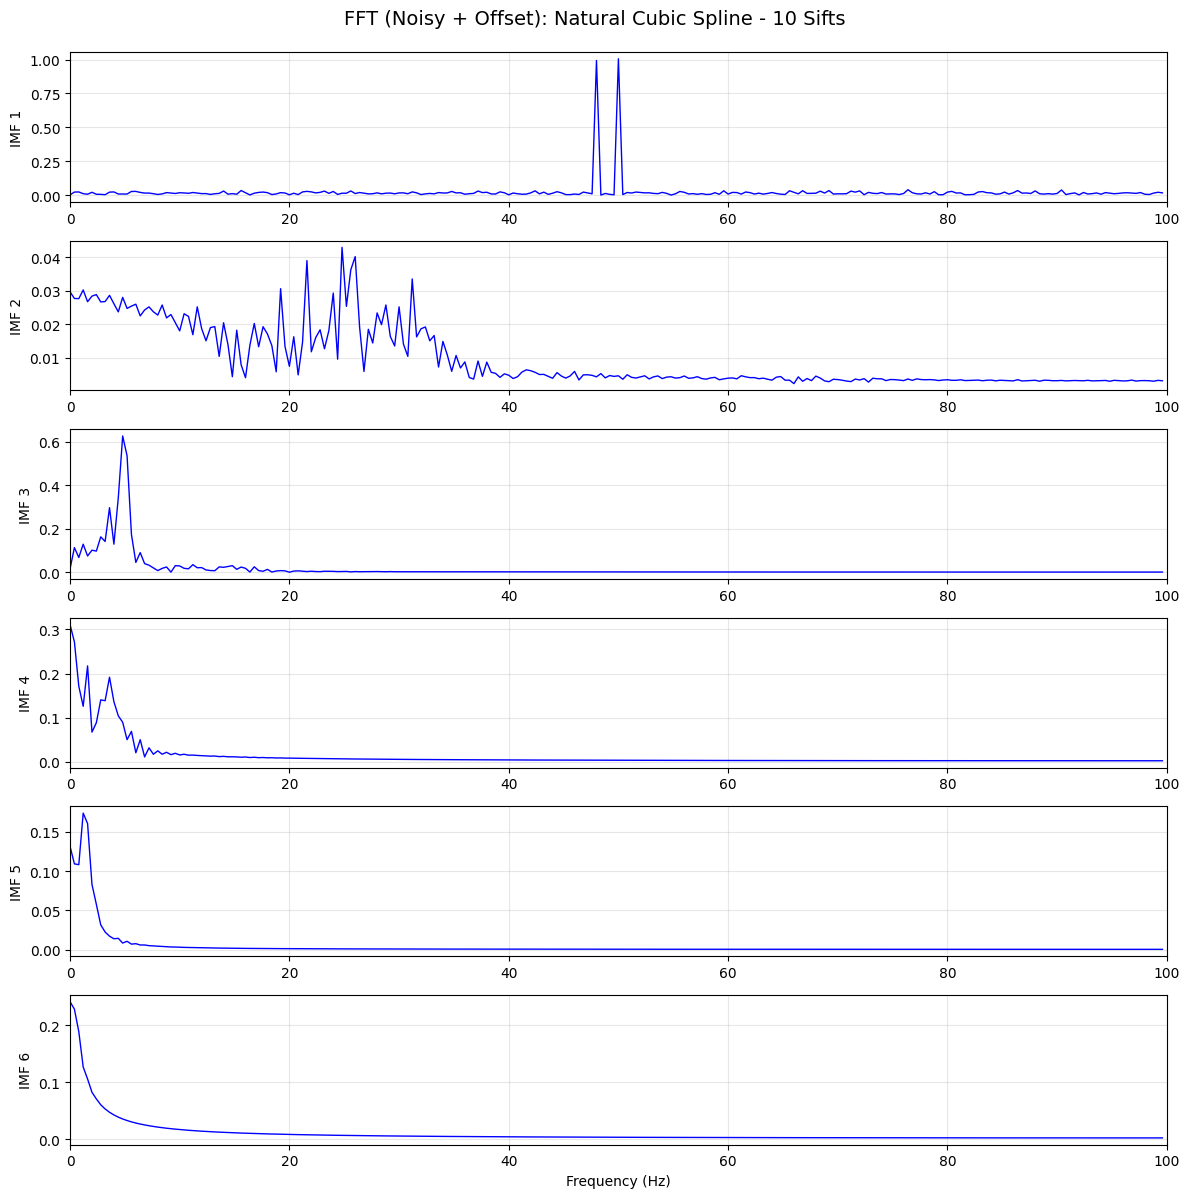

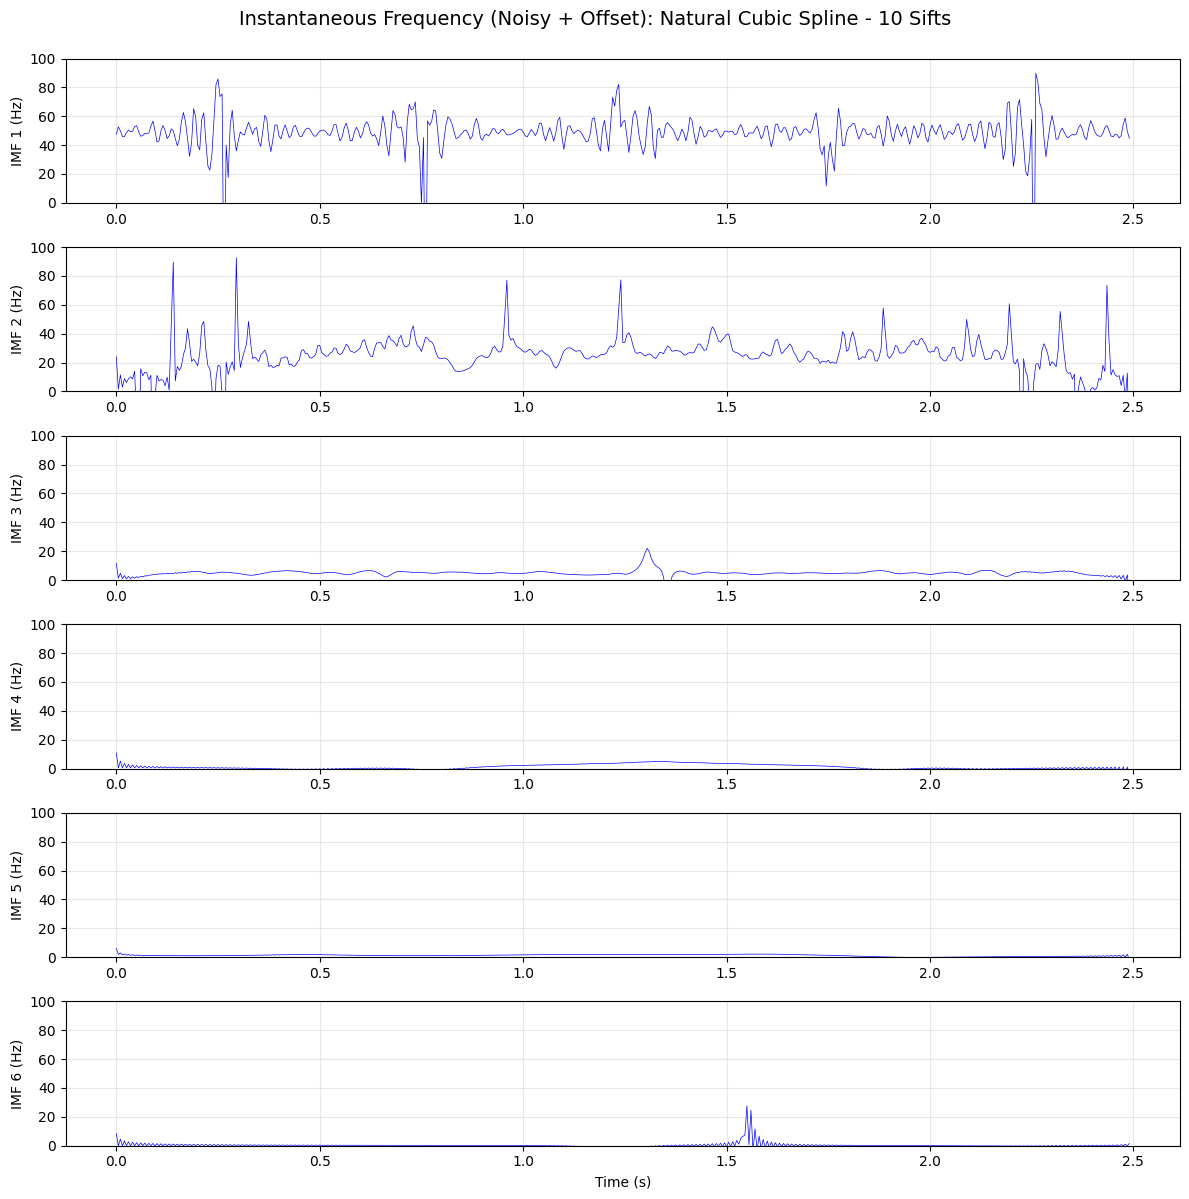

In [80]:
# EMD on noisy signal with Natural Cubic Spline, 10 sifts
imfs_noisy_cubic_10, residue_noisy_cubic_10 = emd(signal_noisy_offset, time_vector, 
                                                    max_sifts=10, 
                                                    spline_type='cubic',
                                                    use_default_stopping=False,
                                                    visualize_first_imf=True)

n_imfs = plot_imfs(imfs_noisy_cubic_10, residue_noisy_cubic_10, time_vector,
                   "EMD (Noisy + Offset): Natural Cubic Spline - 10 Sifts")

plot_imf_ffts(imfs_noisy_cubic_10, sr, "FFT (Noisy + Offset): Natural Cubic Spline - 10 Sifts")
plot_instantaneous_frequencies(imfs_noisy_cubic_10, time_vector, sr,
                               "Instantaneous Frequency (Noisy + Offset): Natural Cubic Spline - 10 Sifts")

### 2. Natural Cubic Spline - Default Stopping (with Noise and Offset)

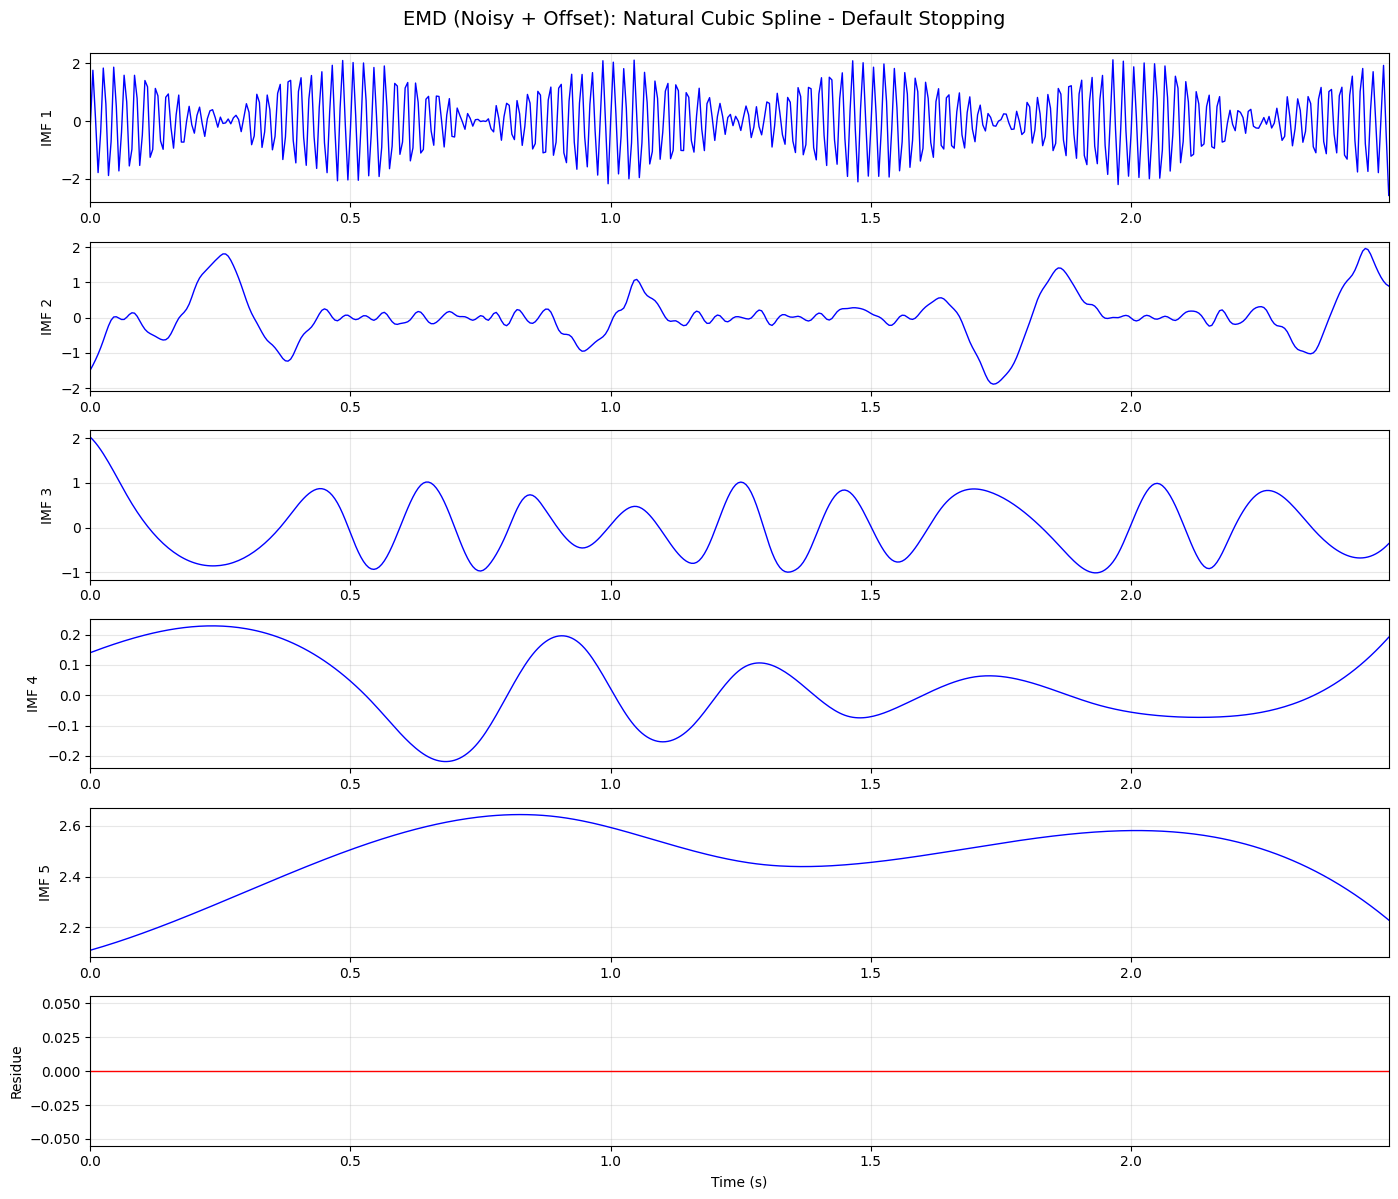

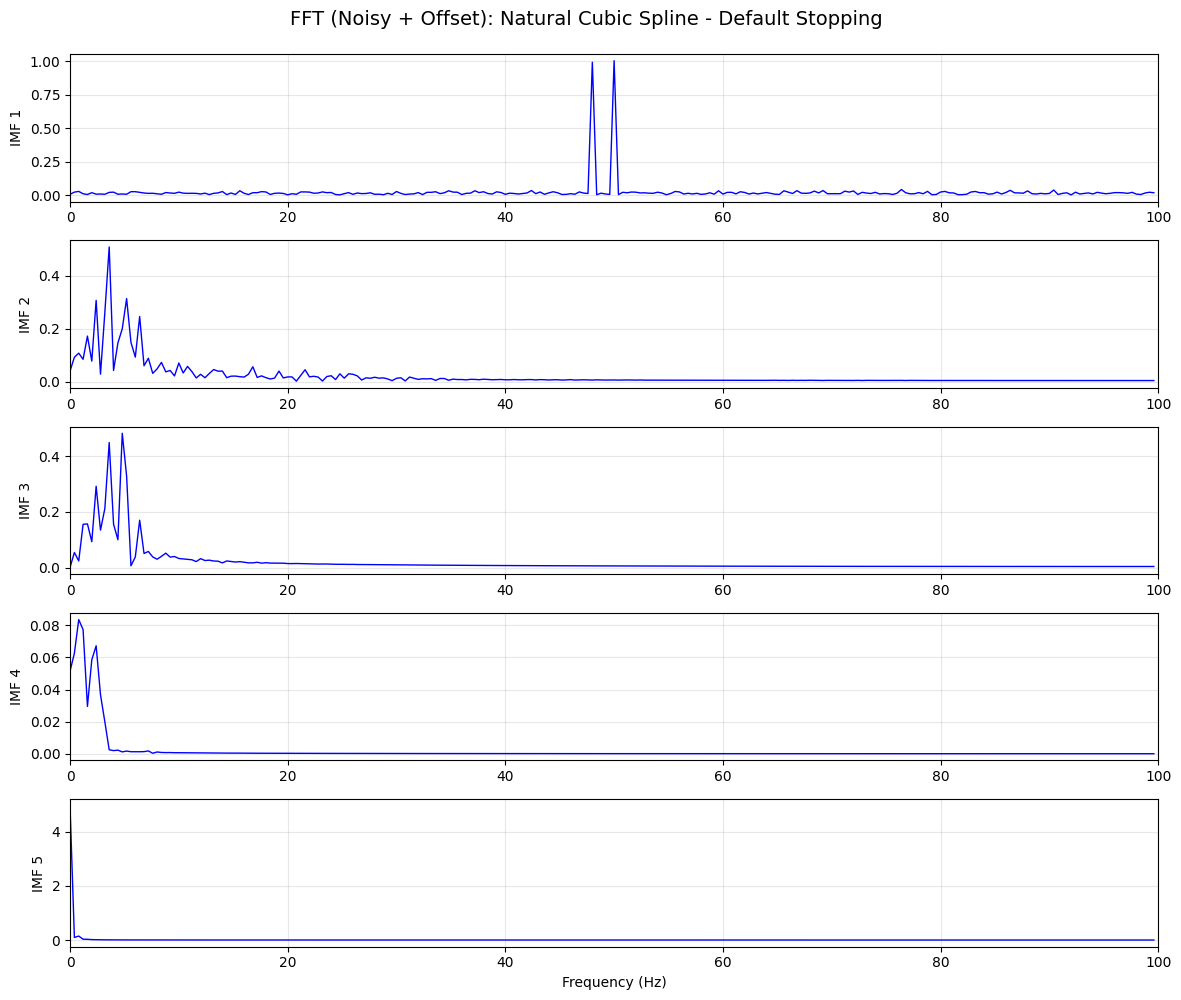

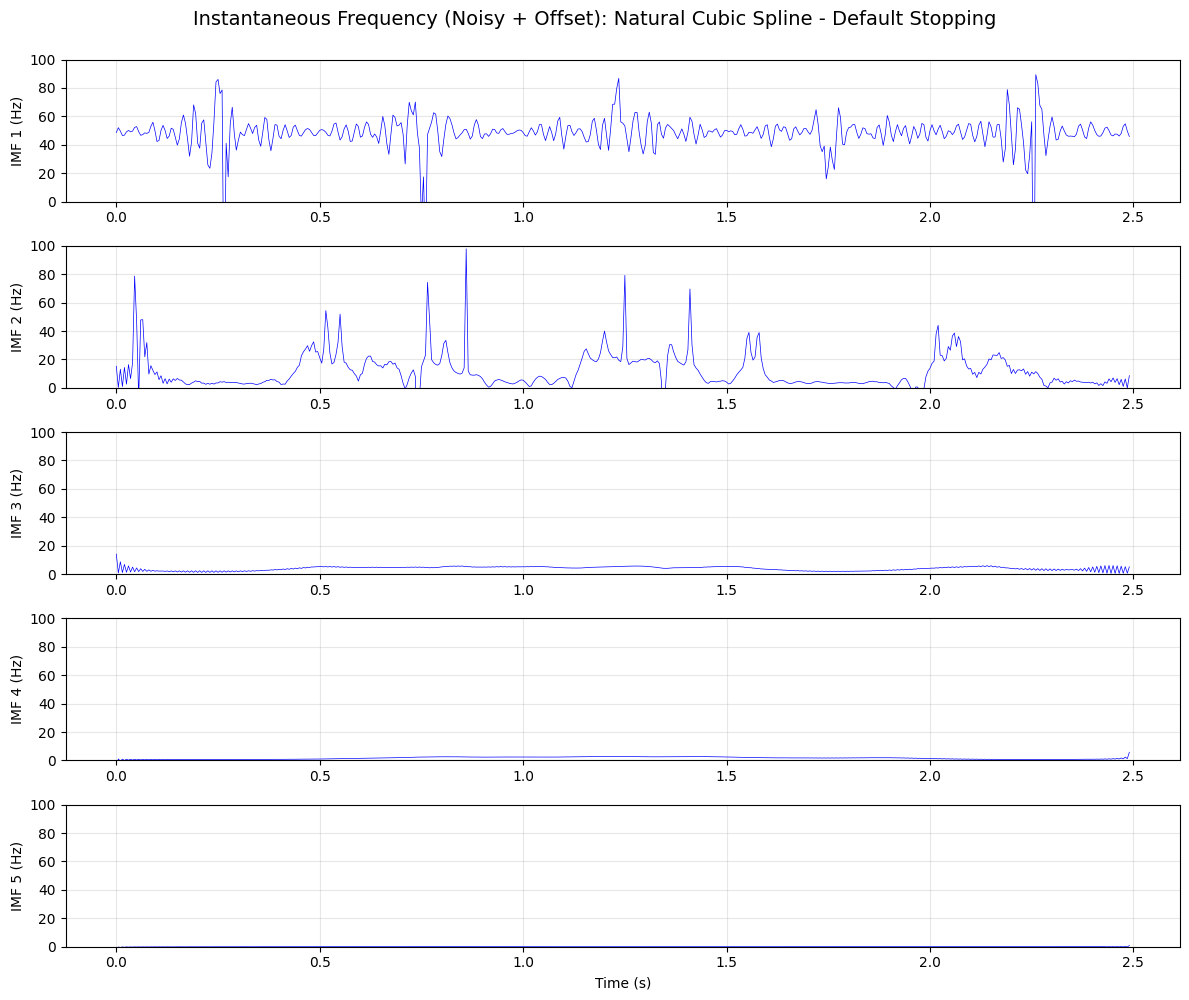

In [81]:
# EMD on noisy signal with Natural Cubic Spline, default stopping
imfs_noisy_cubic_default, residue_noisy_cubic_default = emd(signal_noisy_offset, time_vector,
                                                              spline_type='cubic',
                                                              use_default_stopping=True)

n_imfs = plot_imfs(imfs_noisy_cubic_default, residue_noisy_cubic_default, time_vector,
                   "EMD (Noisy + Offset): Natural Cubic Spline - Default Stopping")

plot_imf_ffts(imfs_noisy_cubic_default, sr, "FFT (Noisy + Offset): Natural Cubic Spline - Default Stopping")
plot_instantaneous_frequencies(imfs_noisy_cubic_default, time_vector, sr,
                               "Instantaneous Frequency (Noisy + Offset): Natural Cubic Spline - Default Stopping")

### 3. Hermite (PCHIP) Spline - 10 Sifts (with Noise and Offset)

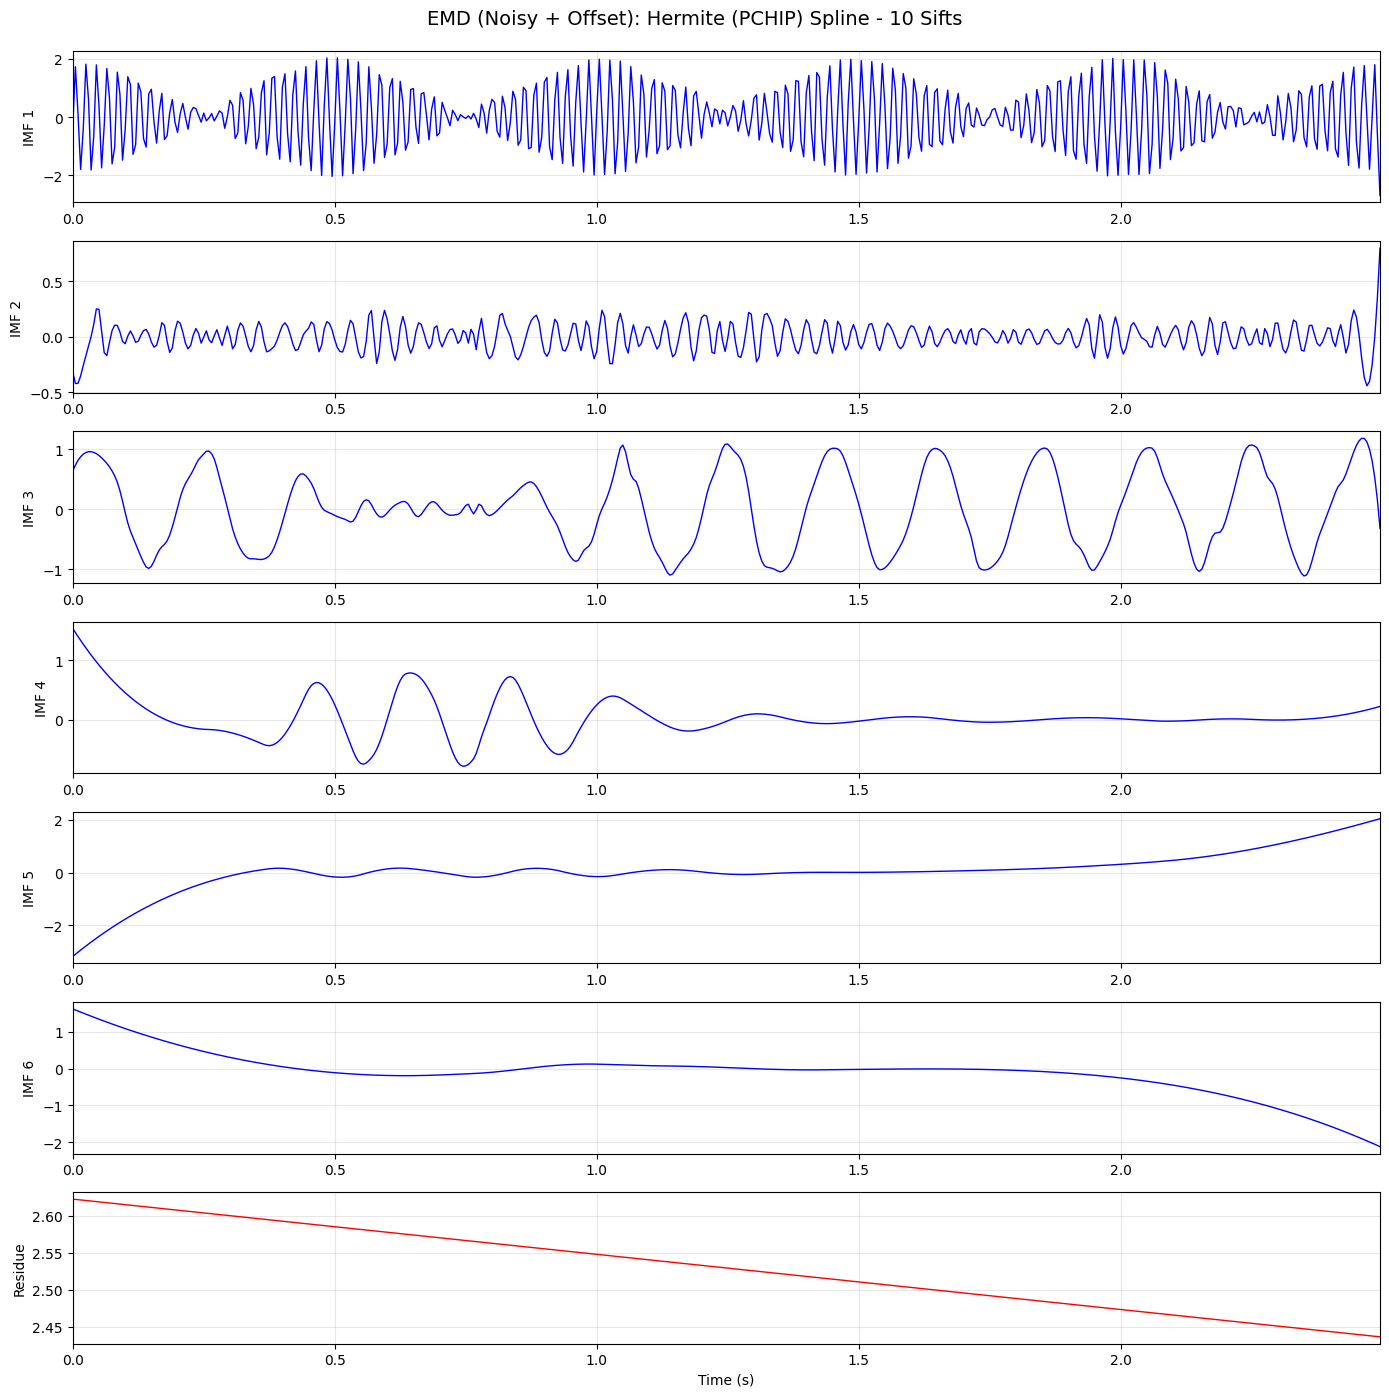

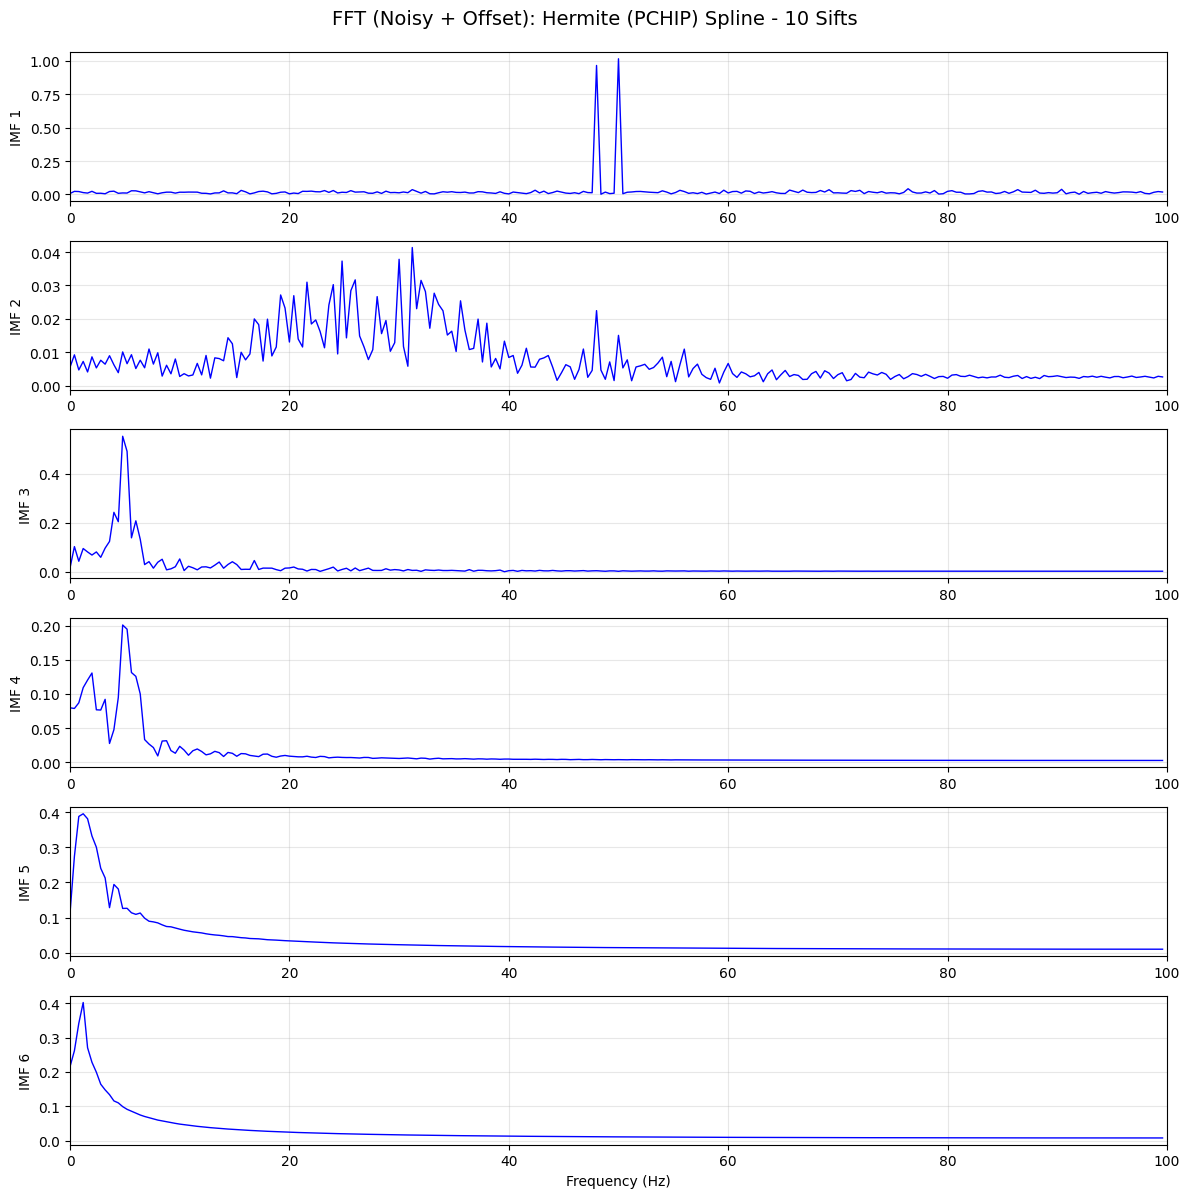

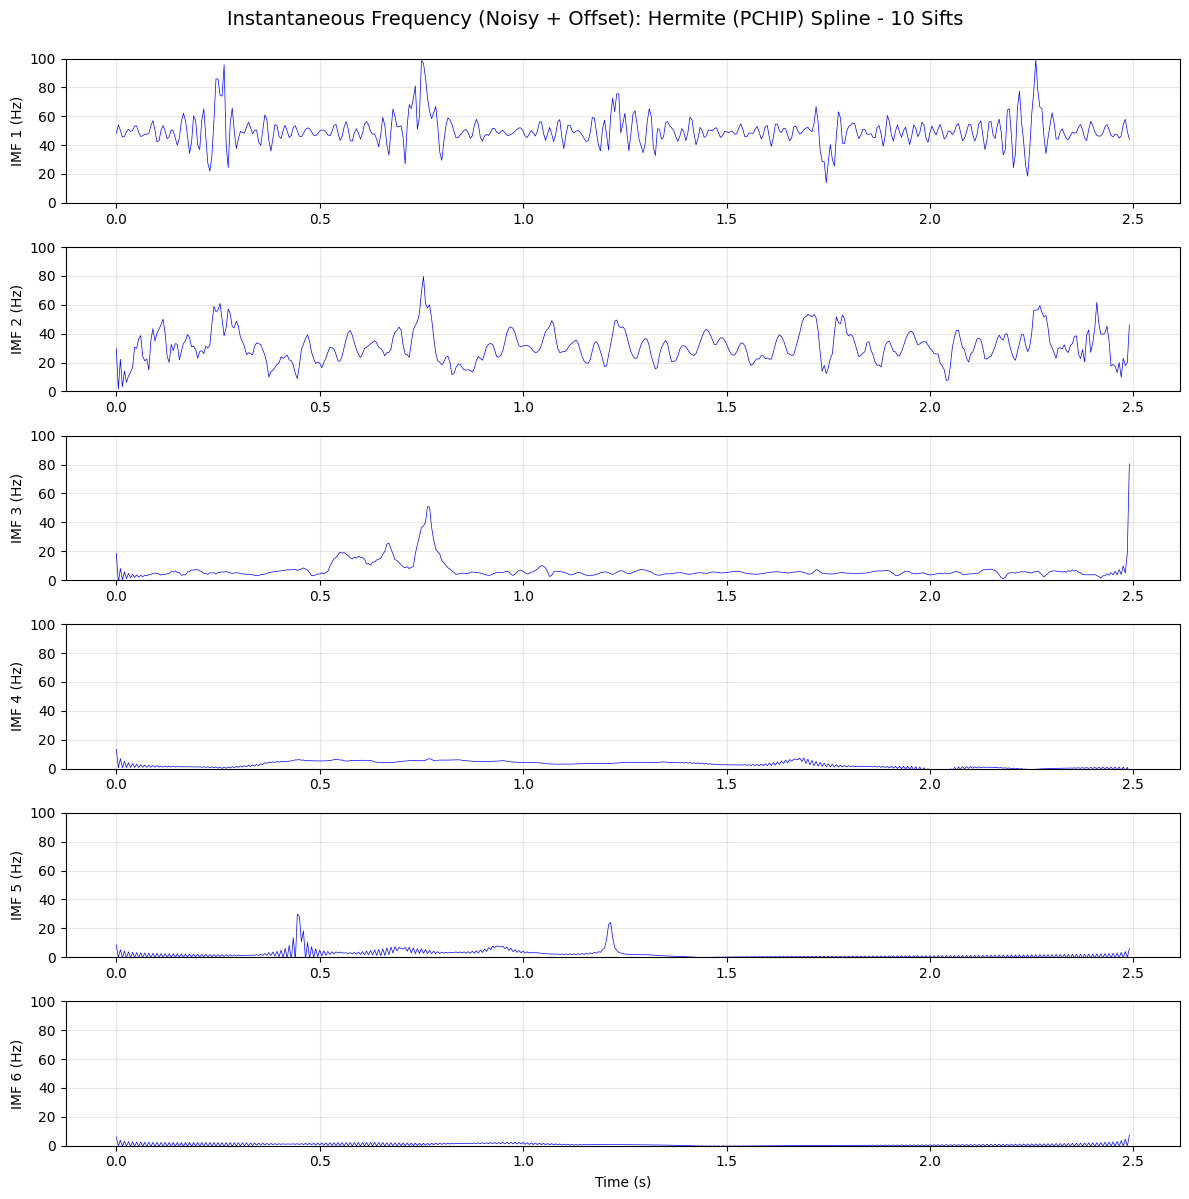

In [82]:
# EMD on noisy signal with Hermite (PCHIP) Spline, 10 sifts
imfs_noisy_pchip_10, residue_noisy_pchip_10 = emd(signal_noisy_offset, time_vector,
                                                    max_sifts=10,
                                                    spline_type='pchip',
                                                    use_default_stopping=False)

n_imfs = plot_imfs(imfs_noisy_pchip_10, residue_noisy_pchip_10, time_vector,
                   "EMD (Noisy + Offset): Hermite (PCHIP) Spline - 10 Sifts")

plot_imf_ffts(imfs_noisy_pchip_10, sr, "FFT (Noisy + Offset): Hermite (PCHIP) Spline - 10 Sifts")
plot_instantaneous_frequencies(imfs_noisy_pchip_10, time_vector, sr,
                               "Instantaneous Frequency (Noisy + Offset): Hermite (PCHIP) Spline - 10 Sifts")

### 4. Hermite (PCHIP) Spline - Default Stopping (with Noise and Offset)

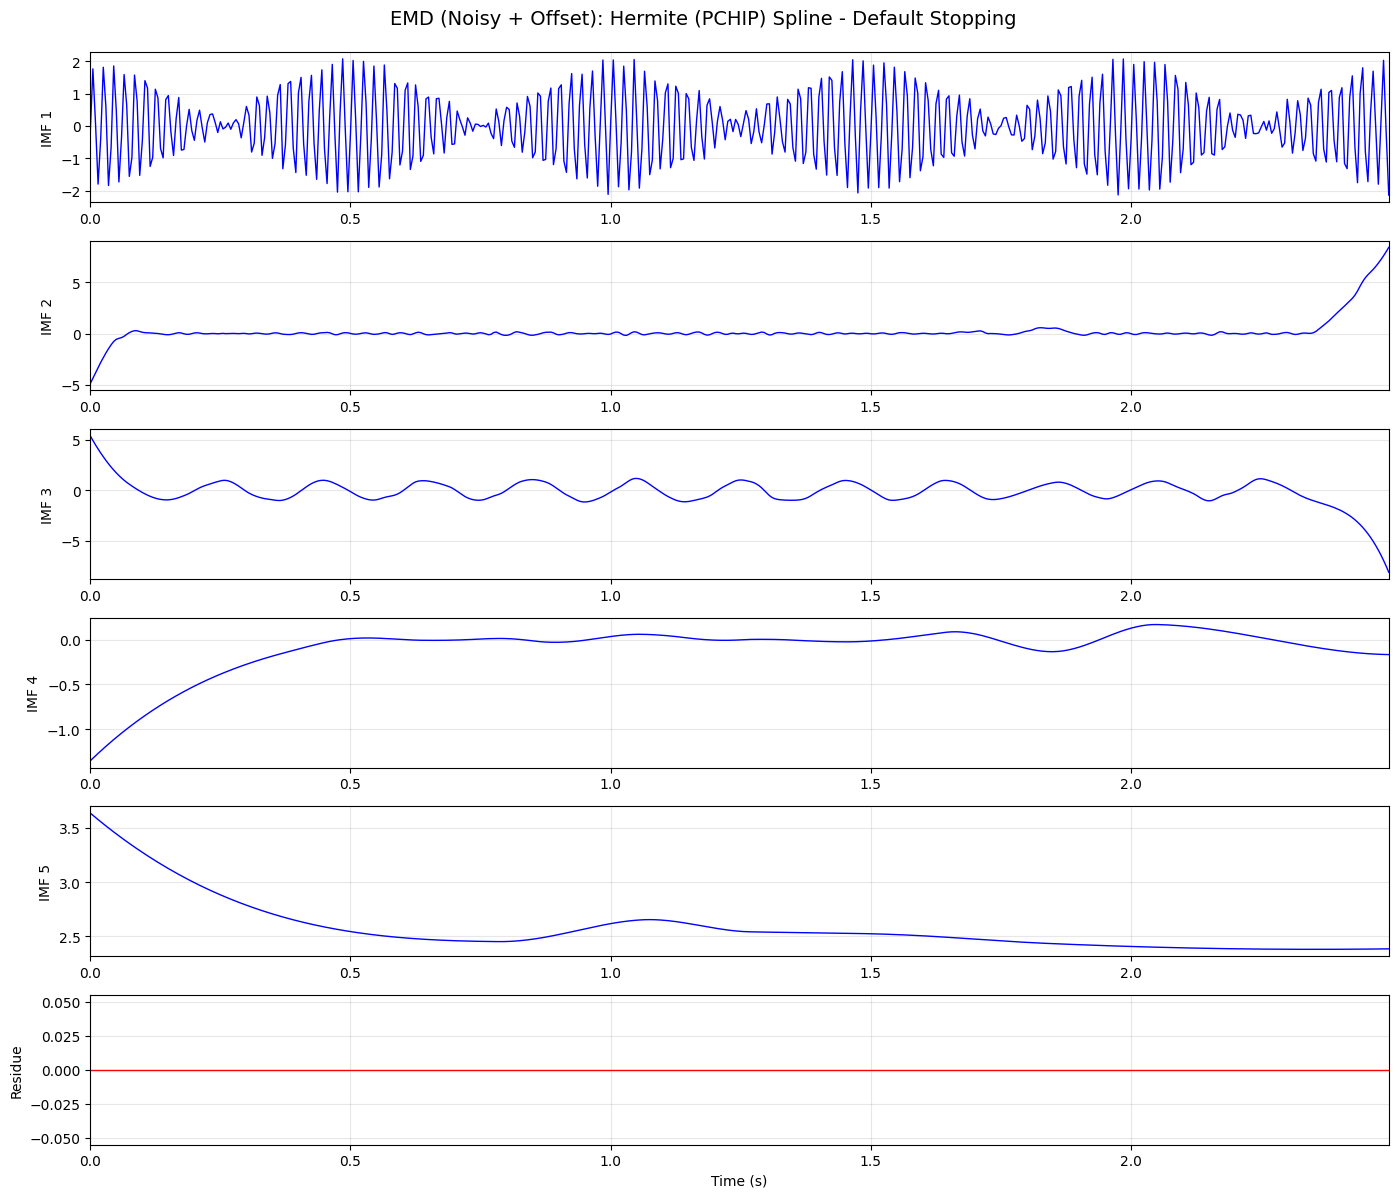

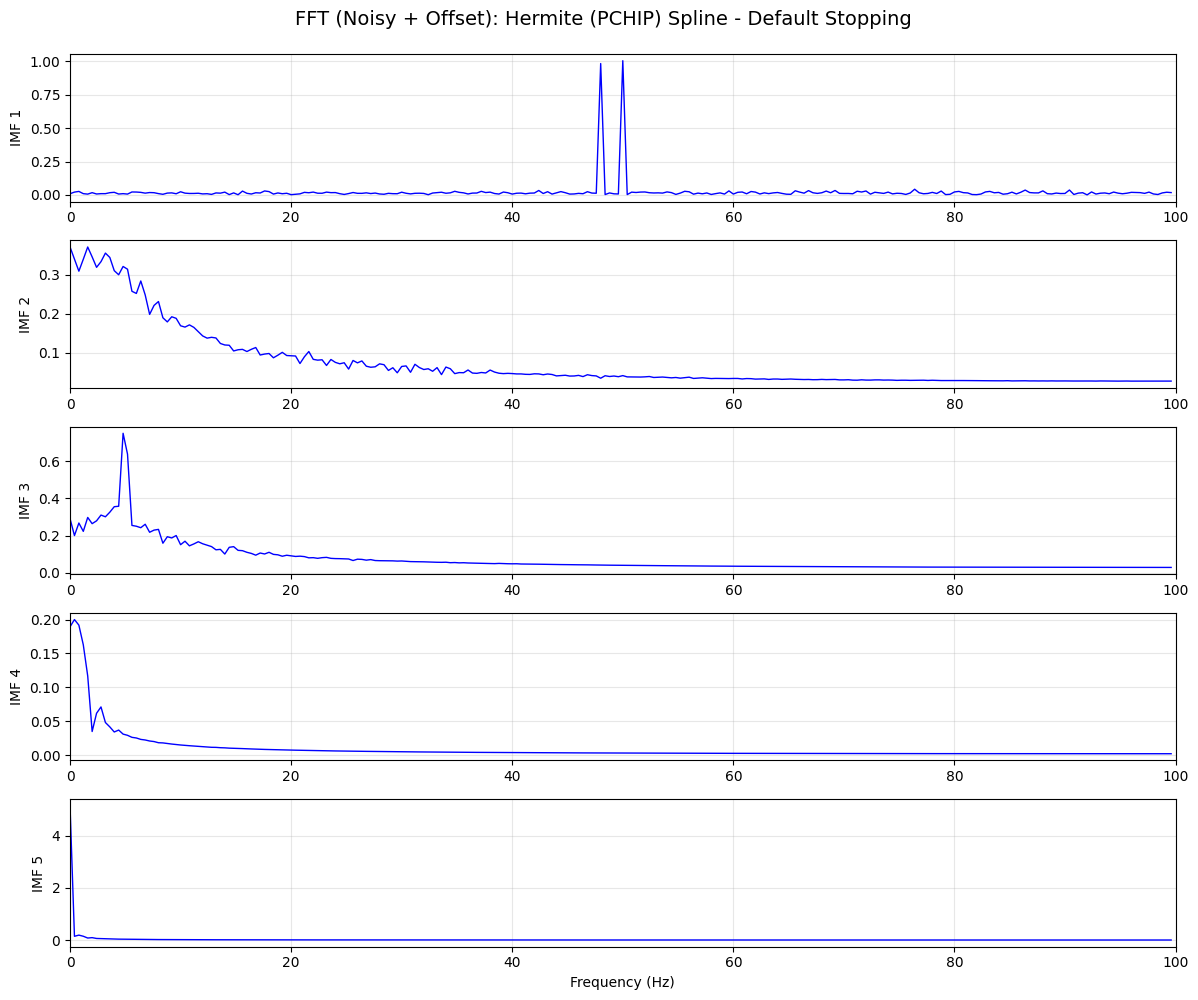

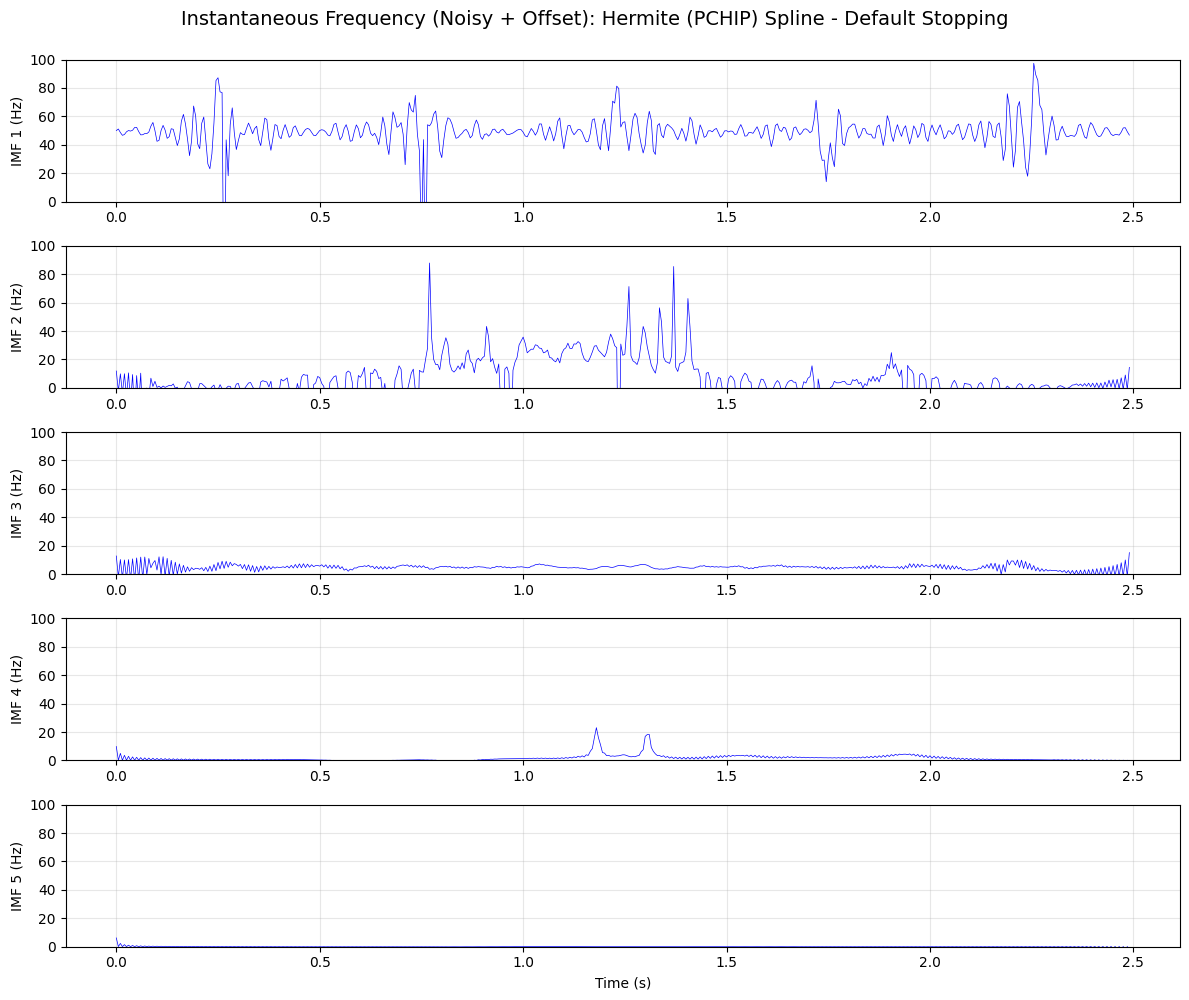

In [83]:
# EMD on noisy signal with Hermite (PCHIP) Spline, default stopping
imfs_noisy_pchip_default, residue_noisy_pchip_default = emd(signal_noisy_offset, time_vector,
                                                              spline_type='pchip',
                                                              use_default_stopping=True)

n_imfs = plot_imfs(imfs_noisy_pchip_default, residue_noisy_pchip_default, time_vector,
                   "EMD (Noisy + Offset): Hermite (PCHIP) Spline - Default Stopping")

plot_imf_ffts(imfs_noisy_pchip_default, sr, "FFT (Noisy + Offset): Hermite (PCHIP) Spline - Default Stopping")
plot_instantaneous_frequencies(imfs_noisy_pchip_default, time_vector, sr,
                               "Instantaneous Frequency (Noisy + Offset): Hermite (PCHIP) Spline - Default Stopping")

# Real Signal

In [84]:
pip install mne

Note: you may need to restart the kernel to use updated packages.


### Load signal

Reading /Users/simenfritzner/Documents/Skole/Semester 9/TTK7/TTK7/GroupWork2/2025-03-10_0924_epo.fif ...
    Read a total of 1 projection items:
        Average EEG reference (1 x 32) active
    Found the data of interest:
        t =   -2952.00 ...    3000.00 ms
        0 CTF compensation matrices available
Not setting metadata
20 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Channel 16: C4
Epoch 0: MI_left
Sampling rate: 250 Hz
Epoch time range: -2.952 to 3.000 seconds
Selected window: -1 to 2 seconds
Actual window: -1.000 to 1.996 seconds
Signal length: 750 samples (3.000 seconds)
Signal shape: (750,)


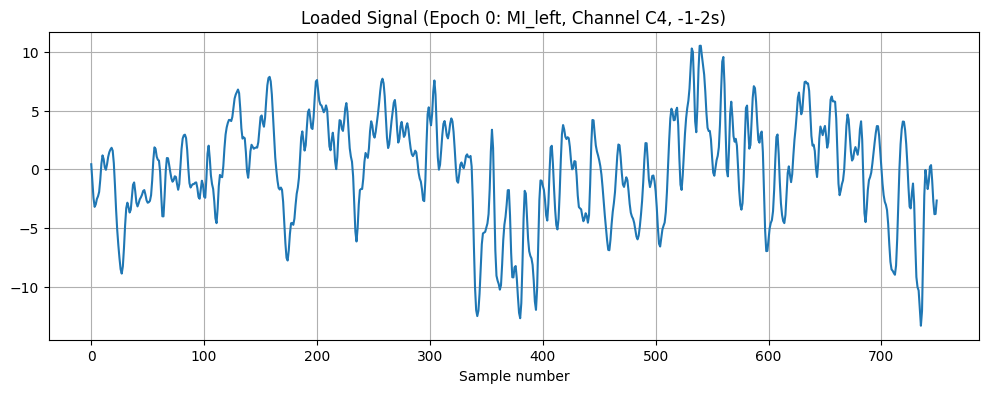

In [85]:
import mne
import numpy as np

# Configuration
epoch_idx = 0
channel_idx = 16
window_start_s = -1
window_end_s = 2

# Load EPO.fif file
epochs = mne.read_epochs('2025-03-10_0924_epo.fif', preload=True)

# Extract sampling rate
sr = int(epochs.info['sfreq'])

# Get channel name
channel_name = epochs.ch_names[channel_idx]

# Get event type for this epoch
event_types = [key for key, val in epochs.event_id.items() if val == epochs.events[epoch_idx, 2]]
event_type = event_types[0] if event_types else "Unknown"

# Get time axis from epochs
epoch_times = epochs.times

# Find indices corresponding to the time window
start_idx = np.argmin(np.abs(epoch_times - window_start_s))
end_idx = np.argmin(np.abs(epoch_times - window_end_s))

# Get the data array (epochs x channels x time)
data = epochs.get_data()

# Extract signal from specified epoch and channel, within time window
signal = data[epoch_idx, channel_idx, start_idx:end_idx]

# Create time vector for the windowed signal
N = len(signal)
time_vector = epoch_times[start_idx:end_idx]

# Display information
print(f"Channel {channel_idx}: {channel_name}")
print(f"Epoch {epoch_idx}: {event_type}")
print(f"Sampling rate: {sr} Hz")
print(f"Epoch time range: {epoch_times[0]:.3f} to {epoch_times[-1]:.3f} seconds")
print(f"Selected window: {window_start_s} to {window_end_s} seconds")
print(f"Actual window: {time_vector[0]:.3f} to {time_vector[-1]:.3f} seconds")
print(f"Signal length: {N} samples ({N/sr:.3f} seconds)")
print(f"Signal shape: {signal.shape}")

# Plot the extracted signal
plotSignal(signal, f'Loaded Signal (Epoch {epoch_idx}: {event_type}, Channel {channel_name}, {window_start_s}-{window_end_s}s)')


## Analysis

## 1. EMD with Natural Cubic Spline - Fixed 10 Sifts

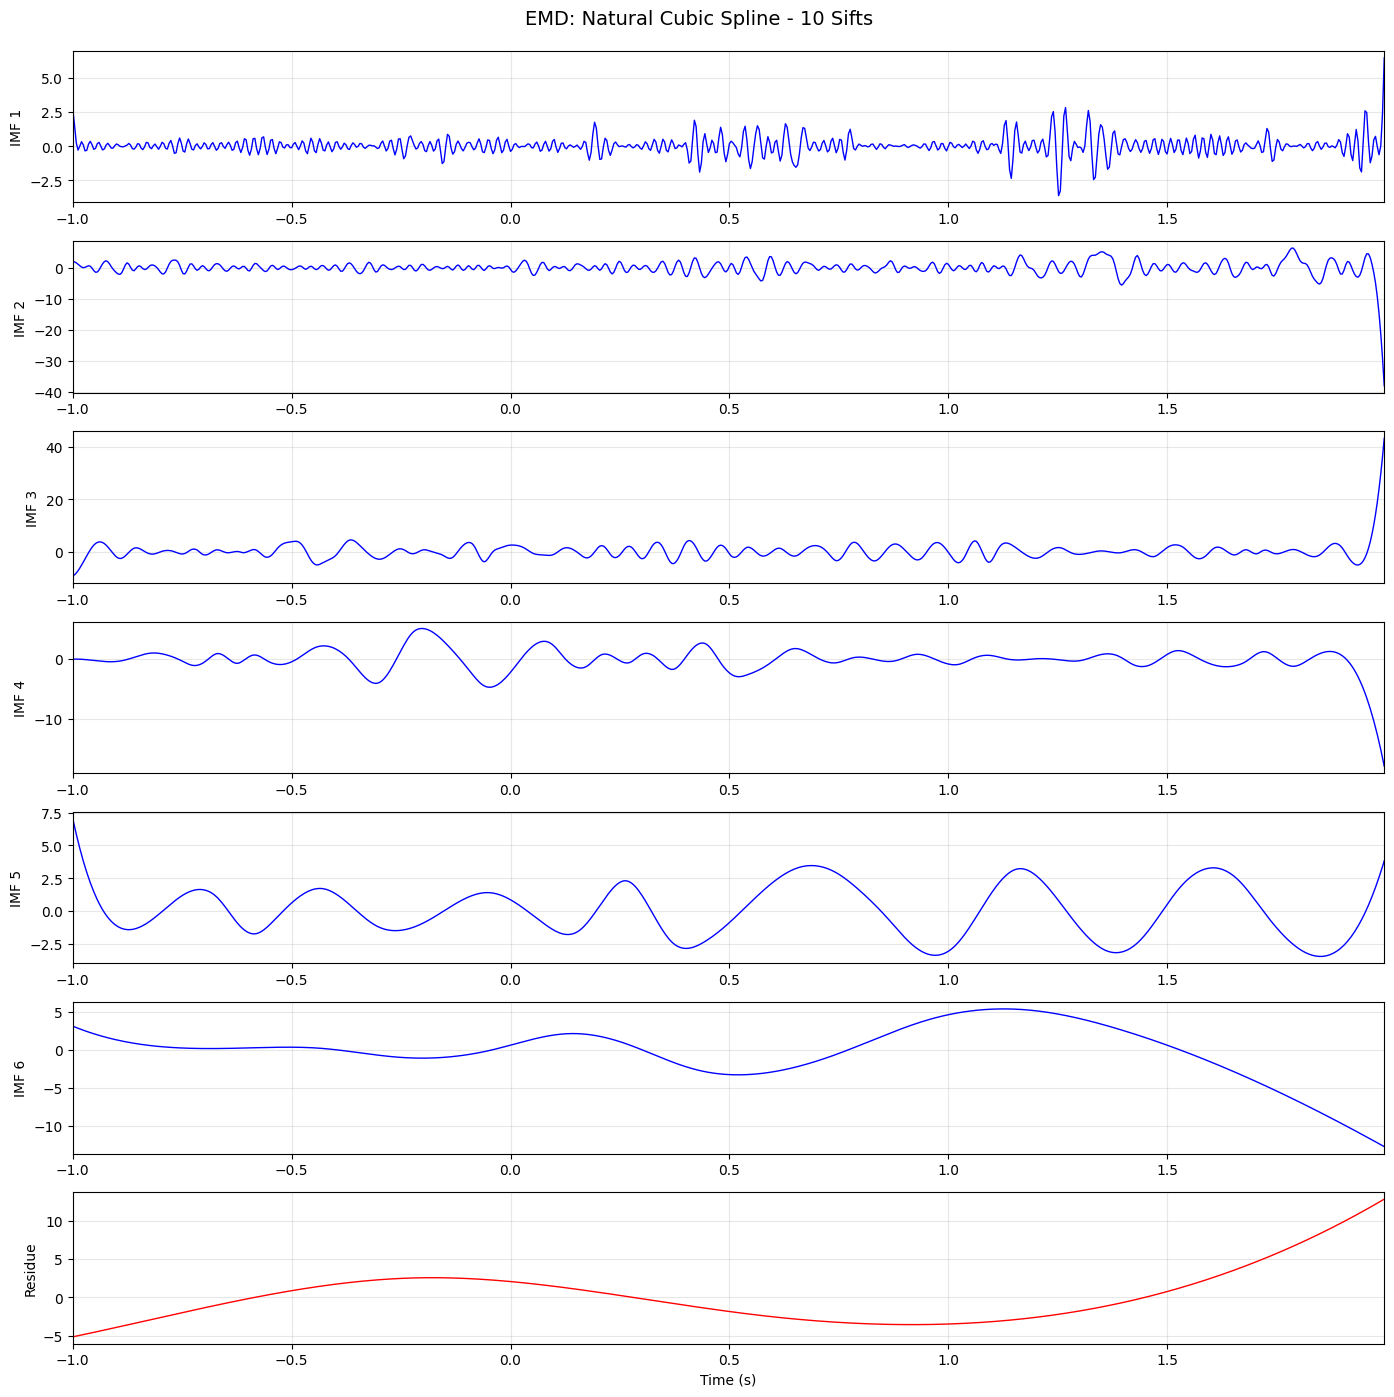

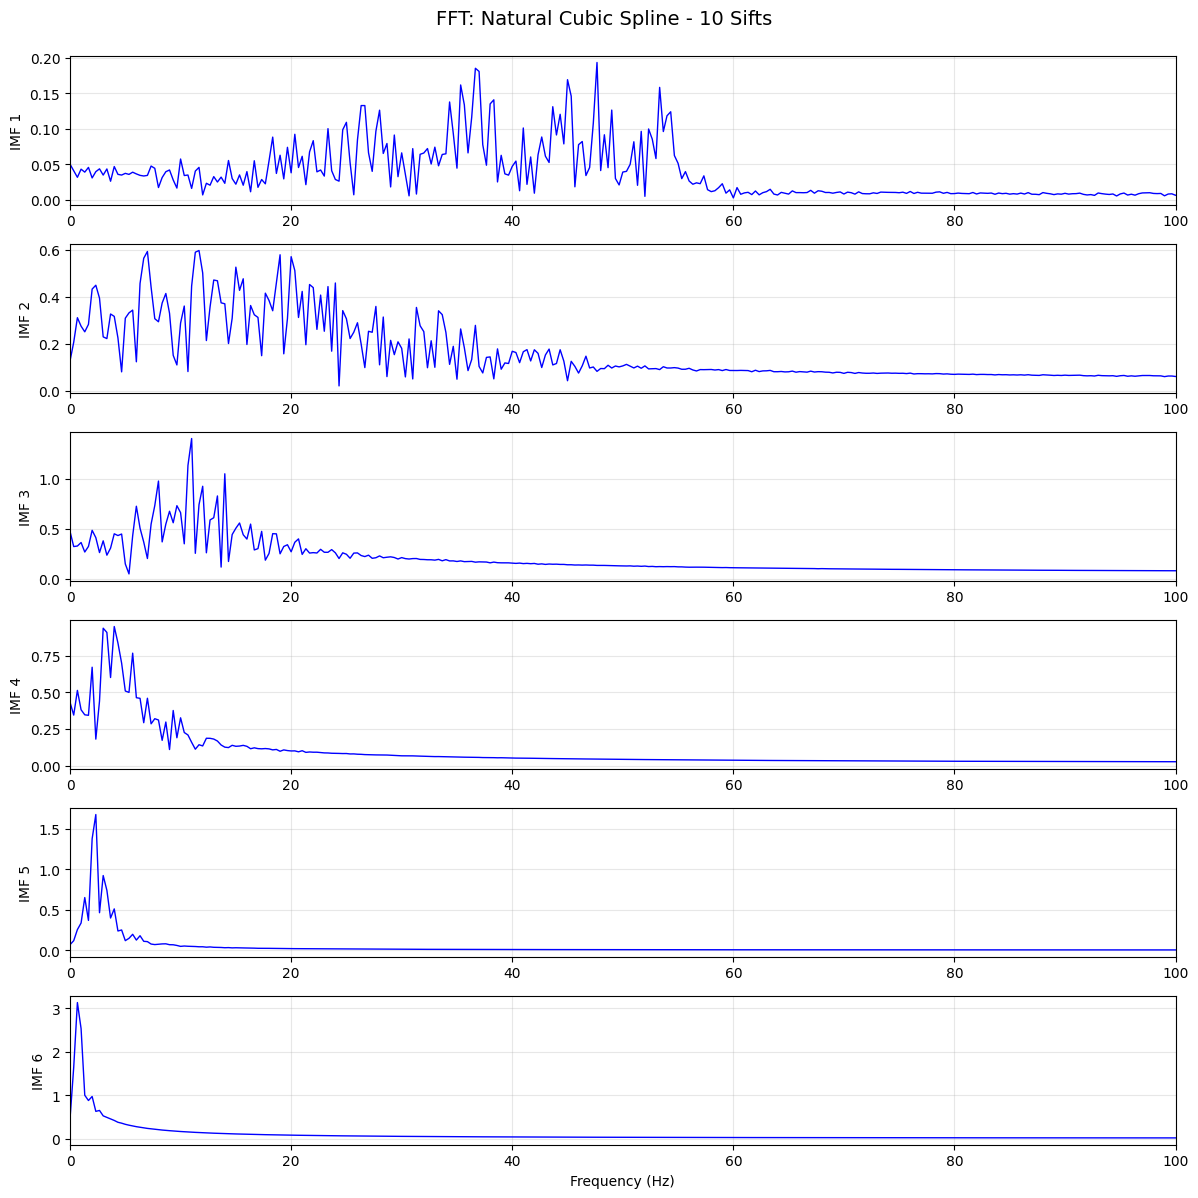

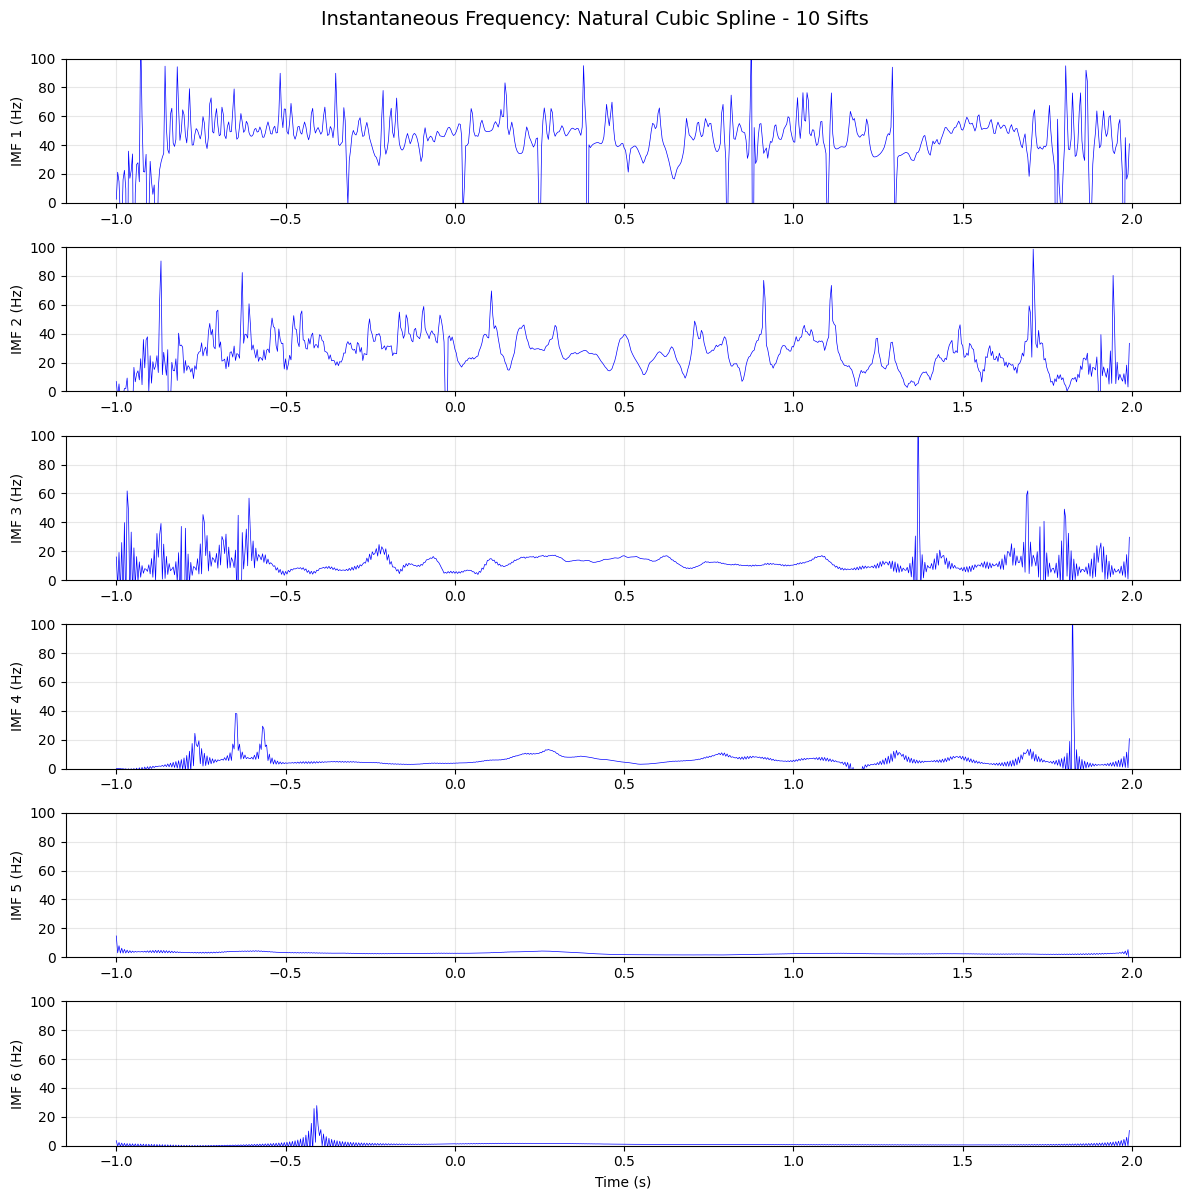

In [86]:
# EMD with Natural Cubic Spline, 10 sifts
imfs_cubic_10, residue_cubic_10 = emd(signal, time_vector, max_sifts=10, 
                                       spline_type='cubic', 
                                       use_default_stopping=False,
                                       visualize_first_imf=True, mask_amp=1.0, mask_freq=70)

n_imfs = plot_imfs(imfs_cubic_10, residue_cubic_10, time_vector, 
                   "EMD: Natural Cubic Spline - 10 Sifts")

plot_imf_ffts(imfs_cubic_10, sr, "FFT: Natural Cubic Spline - 10 Sifts")
plot_instantaneous_frequencies(imfs_cubic_10, time_vector, sr, 
                               "Instantaneous Frequency: Natural Cubic Spline - 10 Sifts")


## 2. EMD with Natural Cubic Spline - Default Stopping Criterion

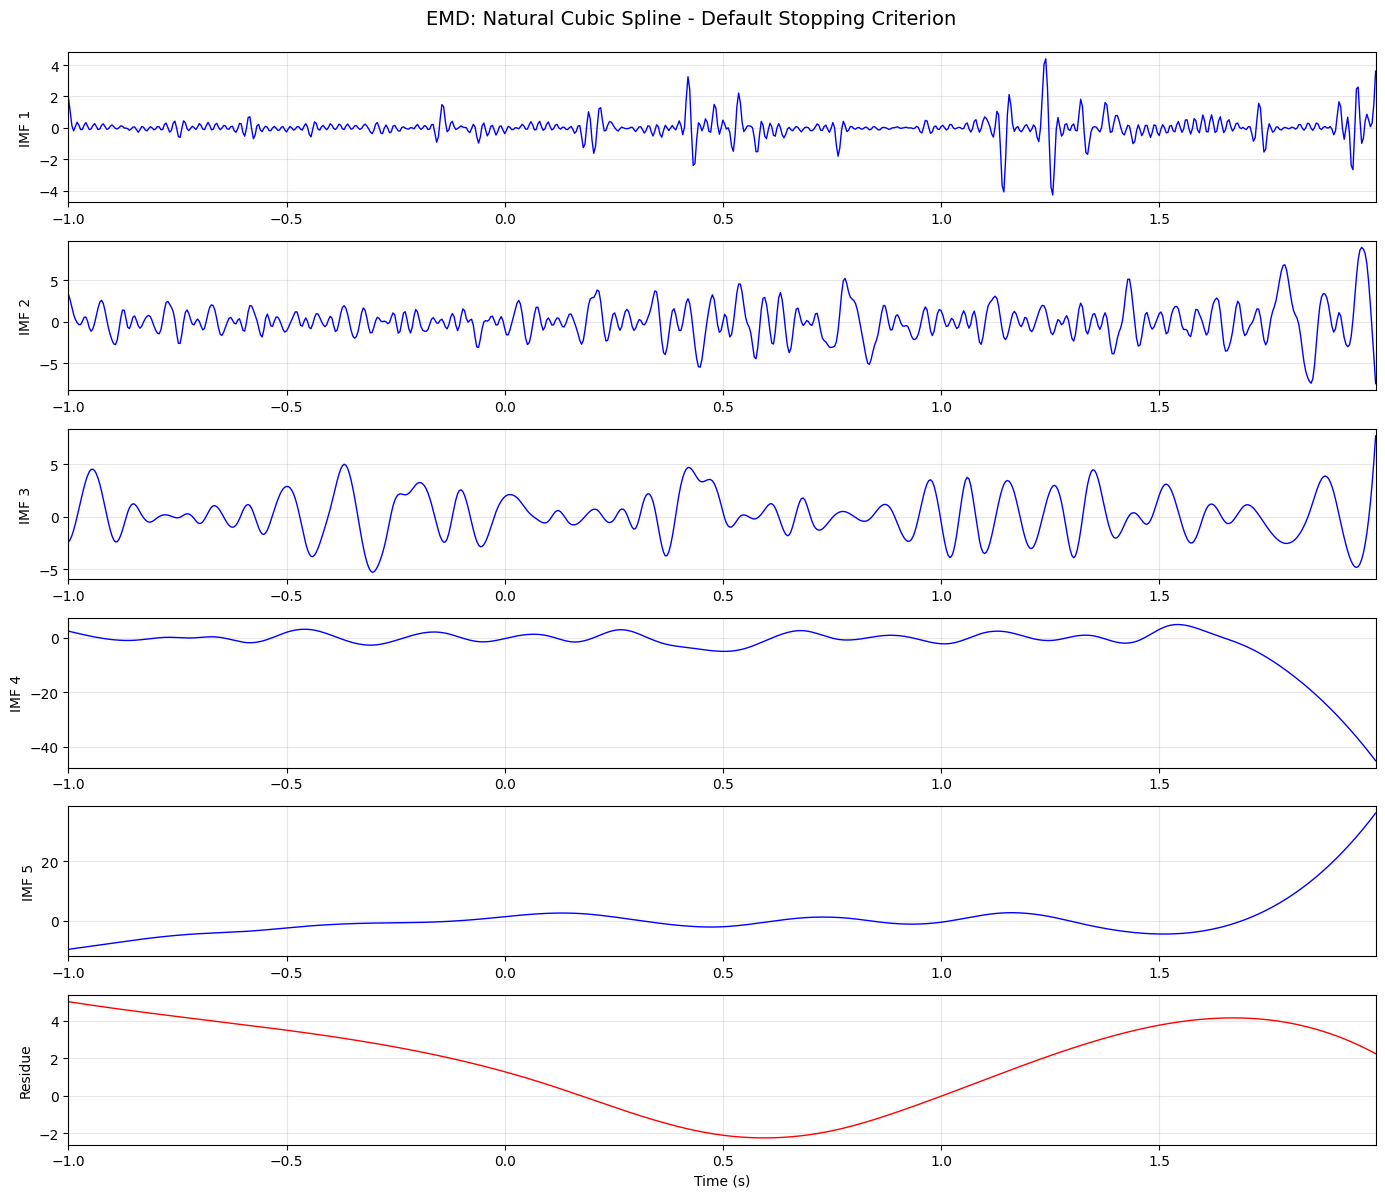

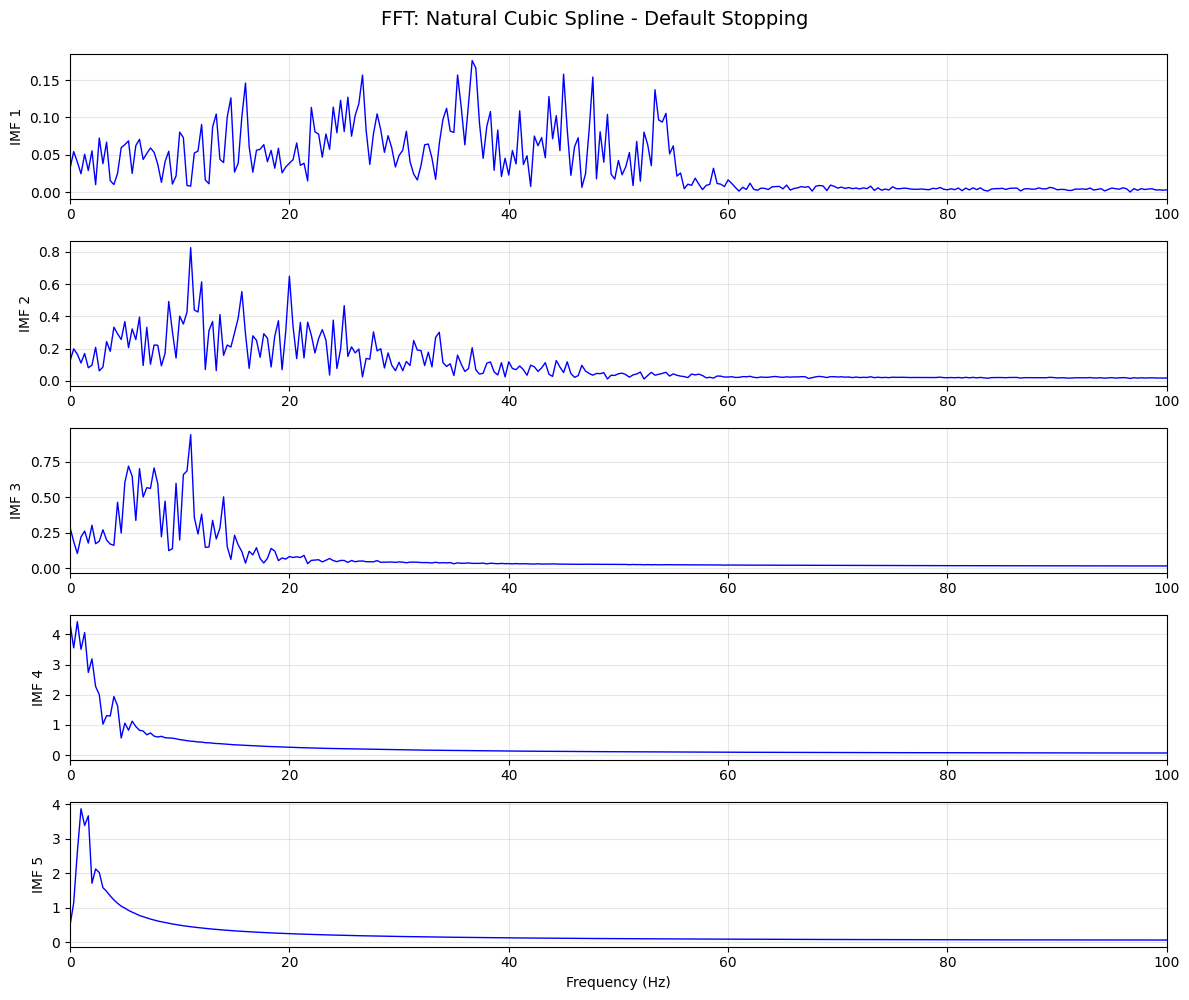

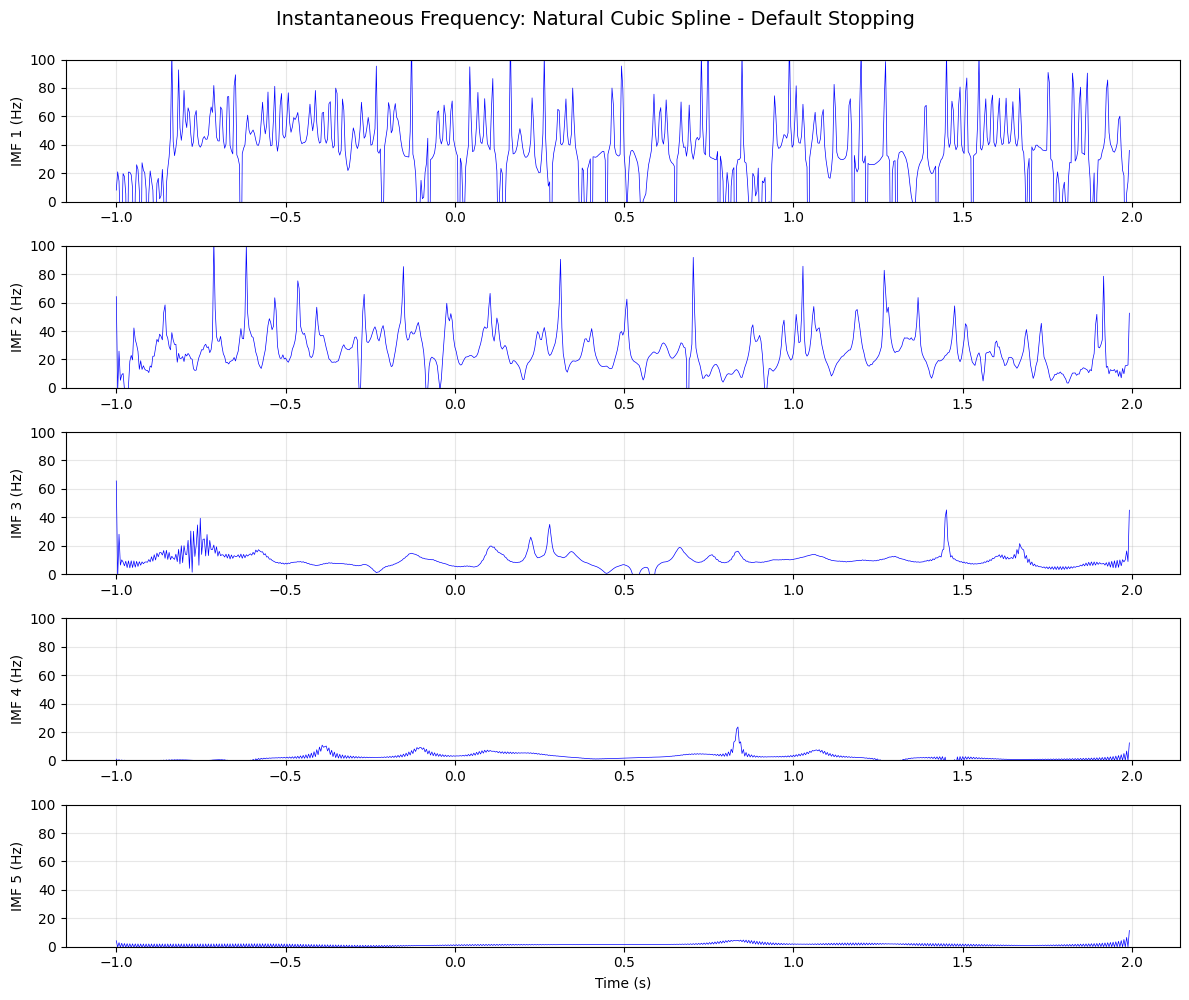

In [87]:
# EMD with Natural Cubic Spline, default stopping (SD < 0.3)
imfs_cubic_default, residue_cubic_default = emd(signal, time_vector, 
                                                 spline_type='cubic',
                                                 use_default_stopping=True)

n_imfs = plot_imfs(imfs_cubic_default, residue_cubic_default, time_vector,
                   "EMD: Natural Cubic Spline - Default Stopping Criterion")

plot_imf_ffts(imfs_cubic_default, sr, "FFT: Natural Cubic Spline - Default Stopping")
plot_instantaneous_frequencies(imfs_cubic_default, time_vector, sr,
                               "Instantaneous Frequency: Natural Cubic Spline - Default Stopping")



## 3. EMD with Hermite (PCHIP) Spline - Fixed 10 Sifts

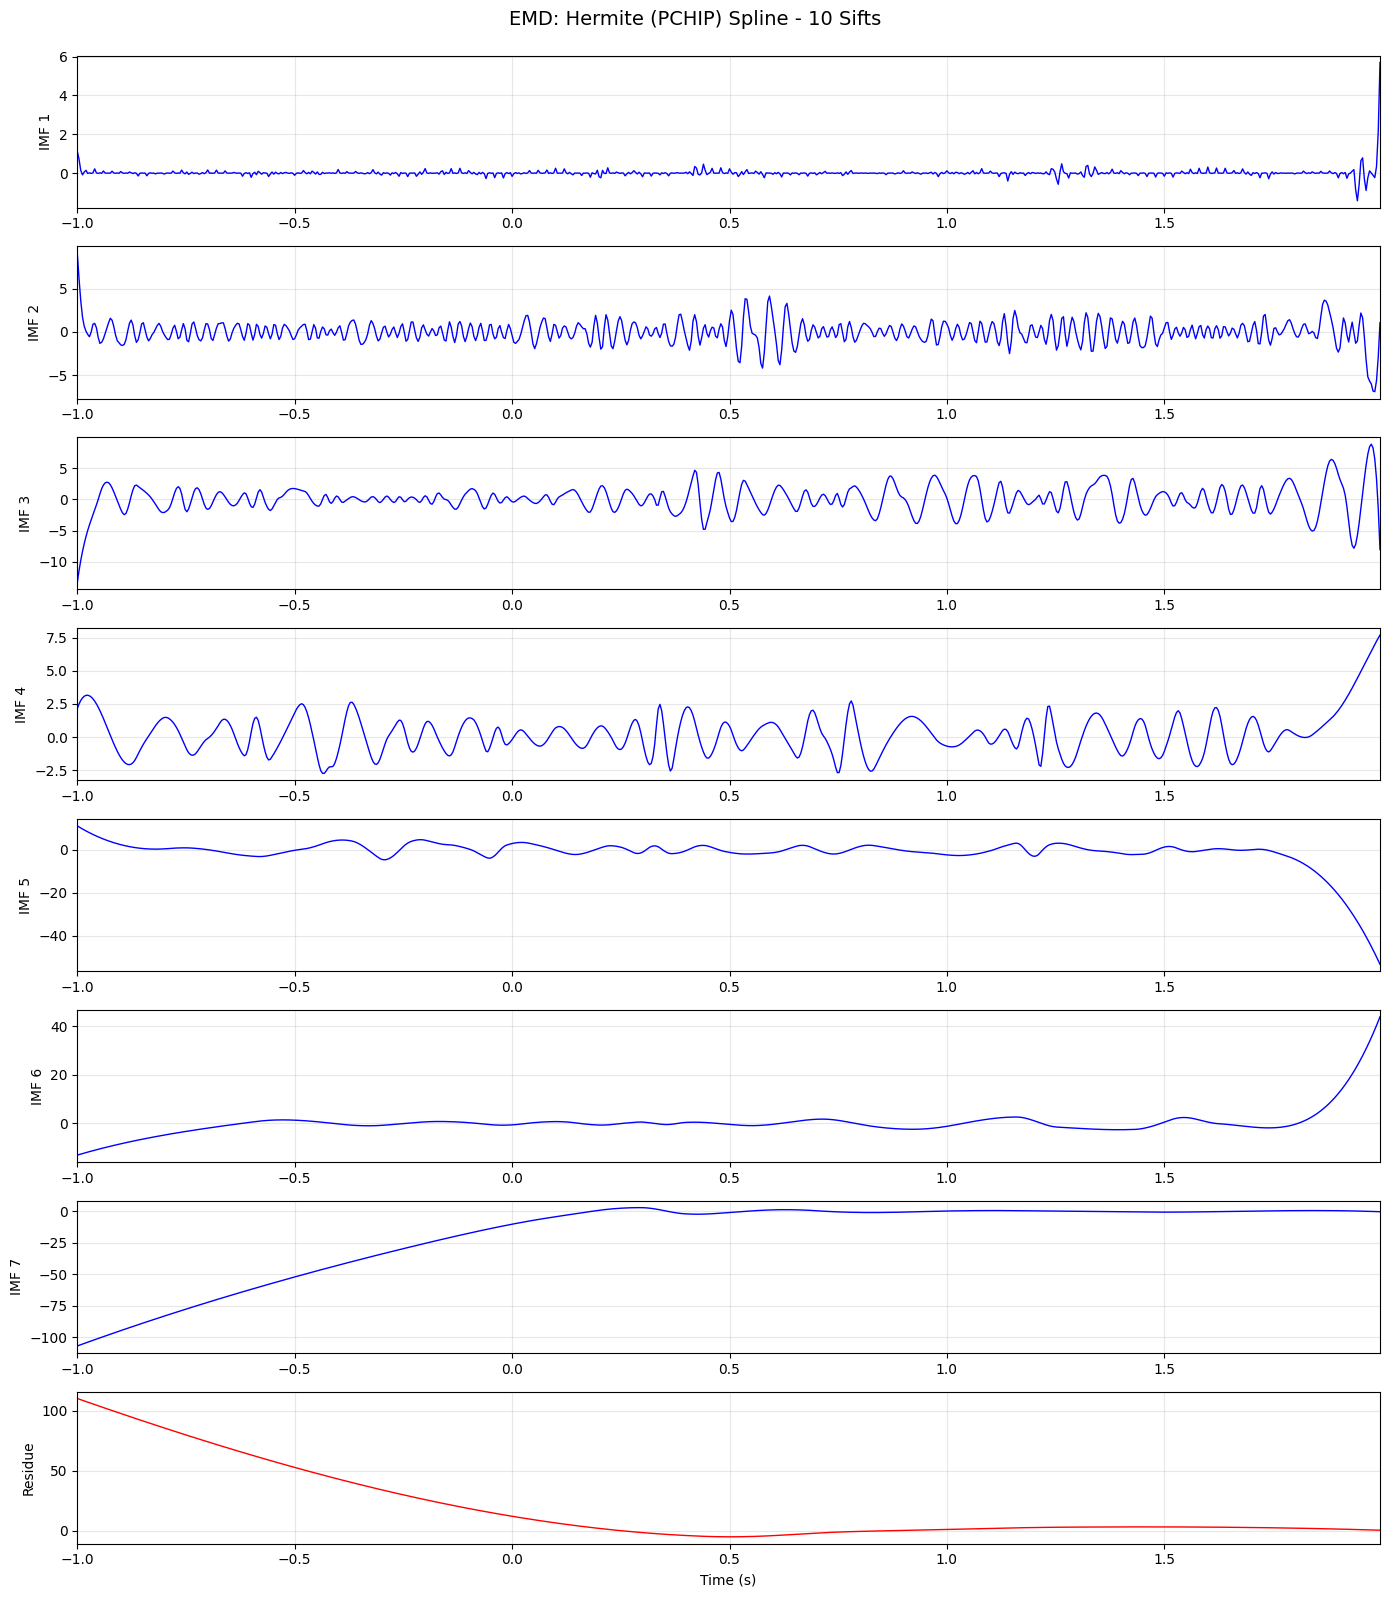

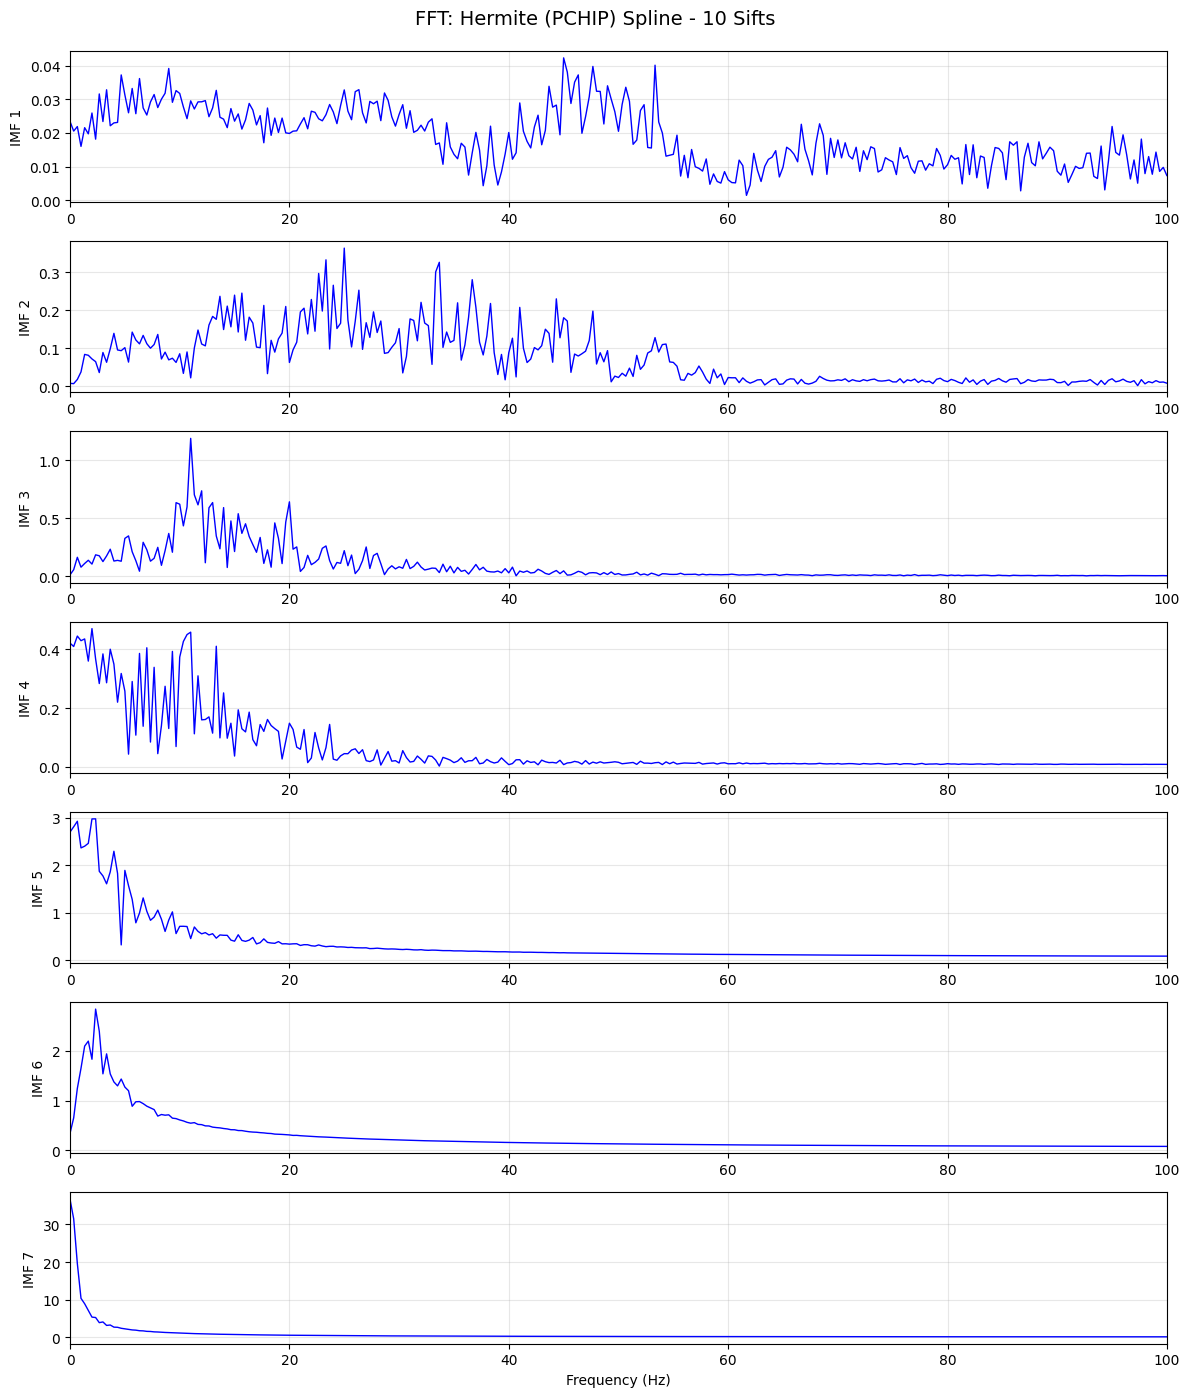

In [88]:
# EMD with Hermite (PCHIP) Spline, 10 sifts
imfs_pchip_10, residue_pchip_10 = emd(signal, time_vector, max_sifts=10,
                                       spline_type='pchip',
                                       use_default_stopping=False)

n_imfs = plot_imfs(imfs_pchip_10, residue_pchip_10, time_vector,
                   "EMD: Hermite (PCHIP) Spline - 10 Sifts")
plot_imf_ffts(imfs_pchip_10, sr, "FFT: Hermite (PCHIP) Spline - 10 Sifts")

## 4. EMD with Hermite (PCHIP) Spline - Default Stopping Criterion

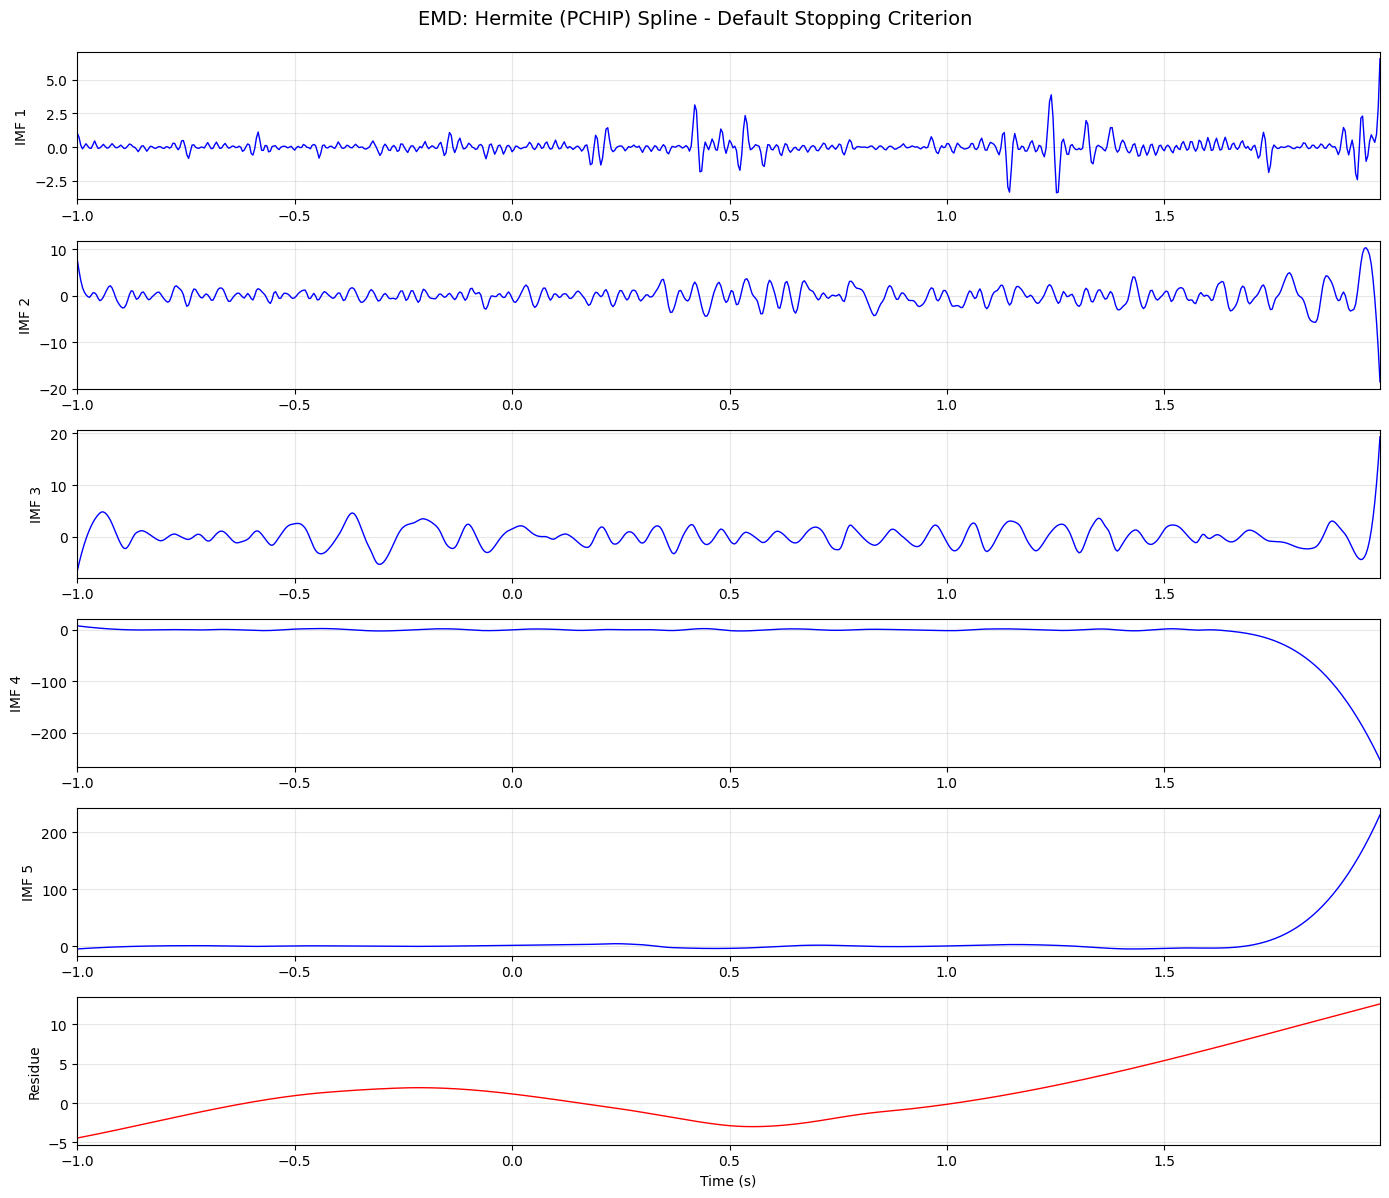

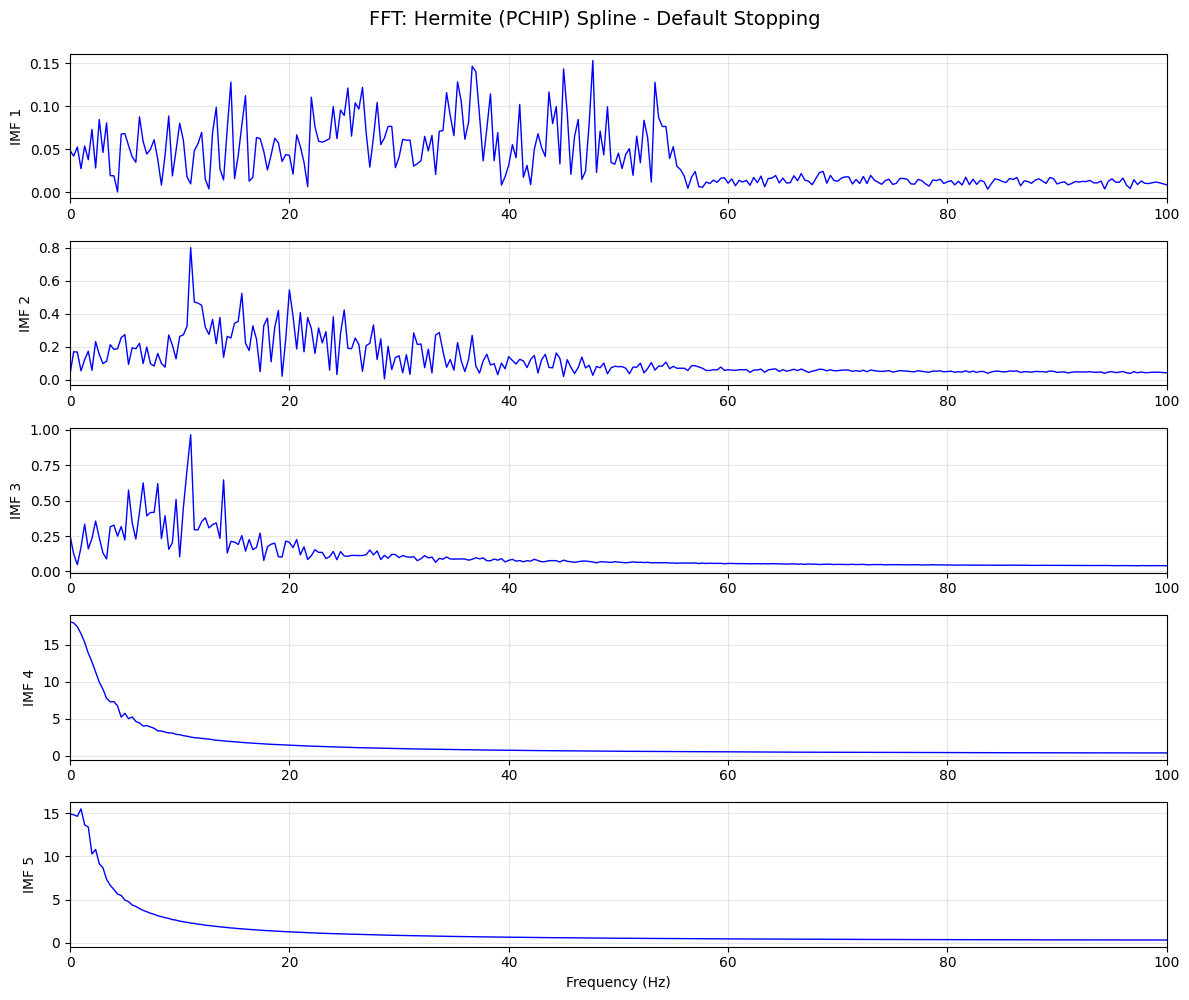

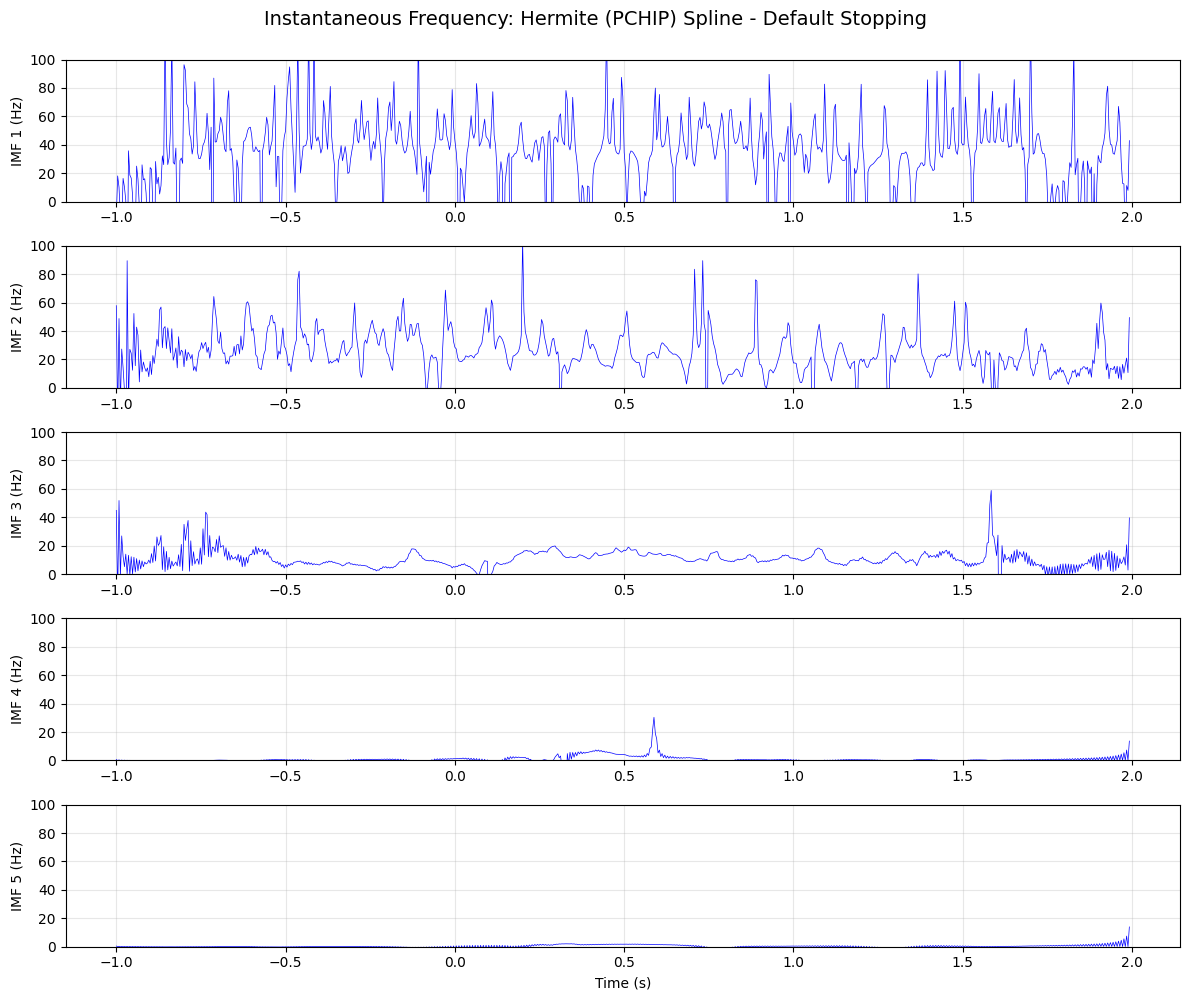

In [ ]:
# EMD with Hermite (PCHIP) Spline, default stopping (SD < 0.3)
imfs_pchip_default, residue_pchip_default = emd(signal, time_vector,
                                                 spline_type='pchip',
                                                 use_default_stopping=True)

n_imfs = plot_imfs(imfs_pchip_default, residue_pchip_default, time_vector,
                   "EMD: Hermite (PCHIP) Spline - Default Stopping Criterion")
plot_imf_ffts(imfs_pchip_default, sr, "FFT: Hermite (PCHIP) Spline - Default Stopping")
plot_instantaneous_frequencies(imfs_pchip_default, time_vector, sr,
                               "Instantaneous Frequency: Hermite (PCHIP) Spline - Default Stopping")

## 5. EEMD Analysis on Real EEG Signal

EEMD provides a more robust decomposition by averaging over multiple noise realizations.

Running EEMD with 100 ensembles...
Noise amplitude: 0.866710 (std ratio: 0.2)
  Processing ensemble 20/100...
  Processing ensemble 40/100...
  Processing ensemble 60/100...
  Processing ensemble 80/100...
  Processing ensemble 100/100...
Maximum IMFs extracted: 7
Averaging across ensembles...
EEMD complete! Extracted 7 averaged IMFs


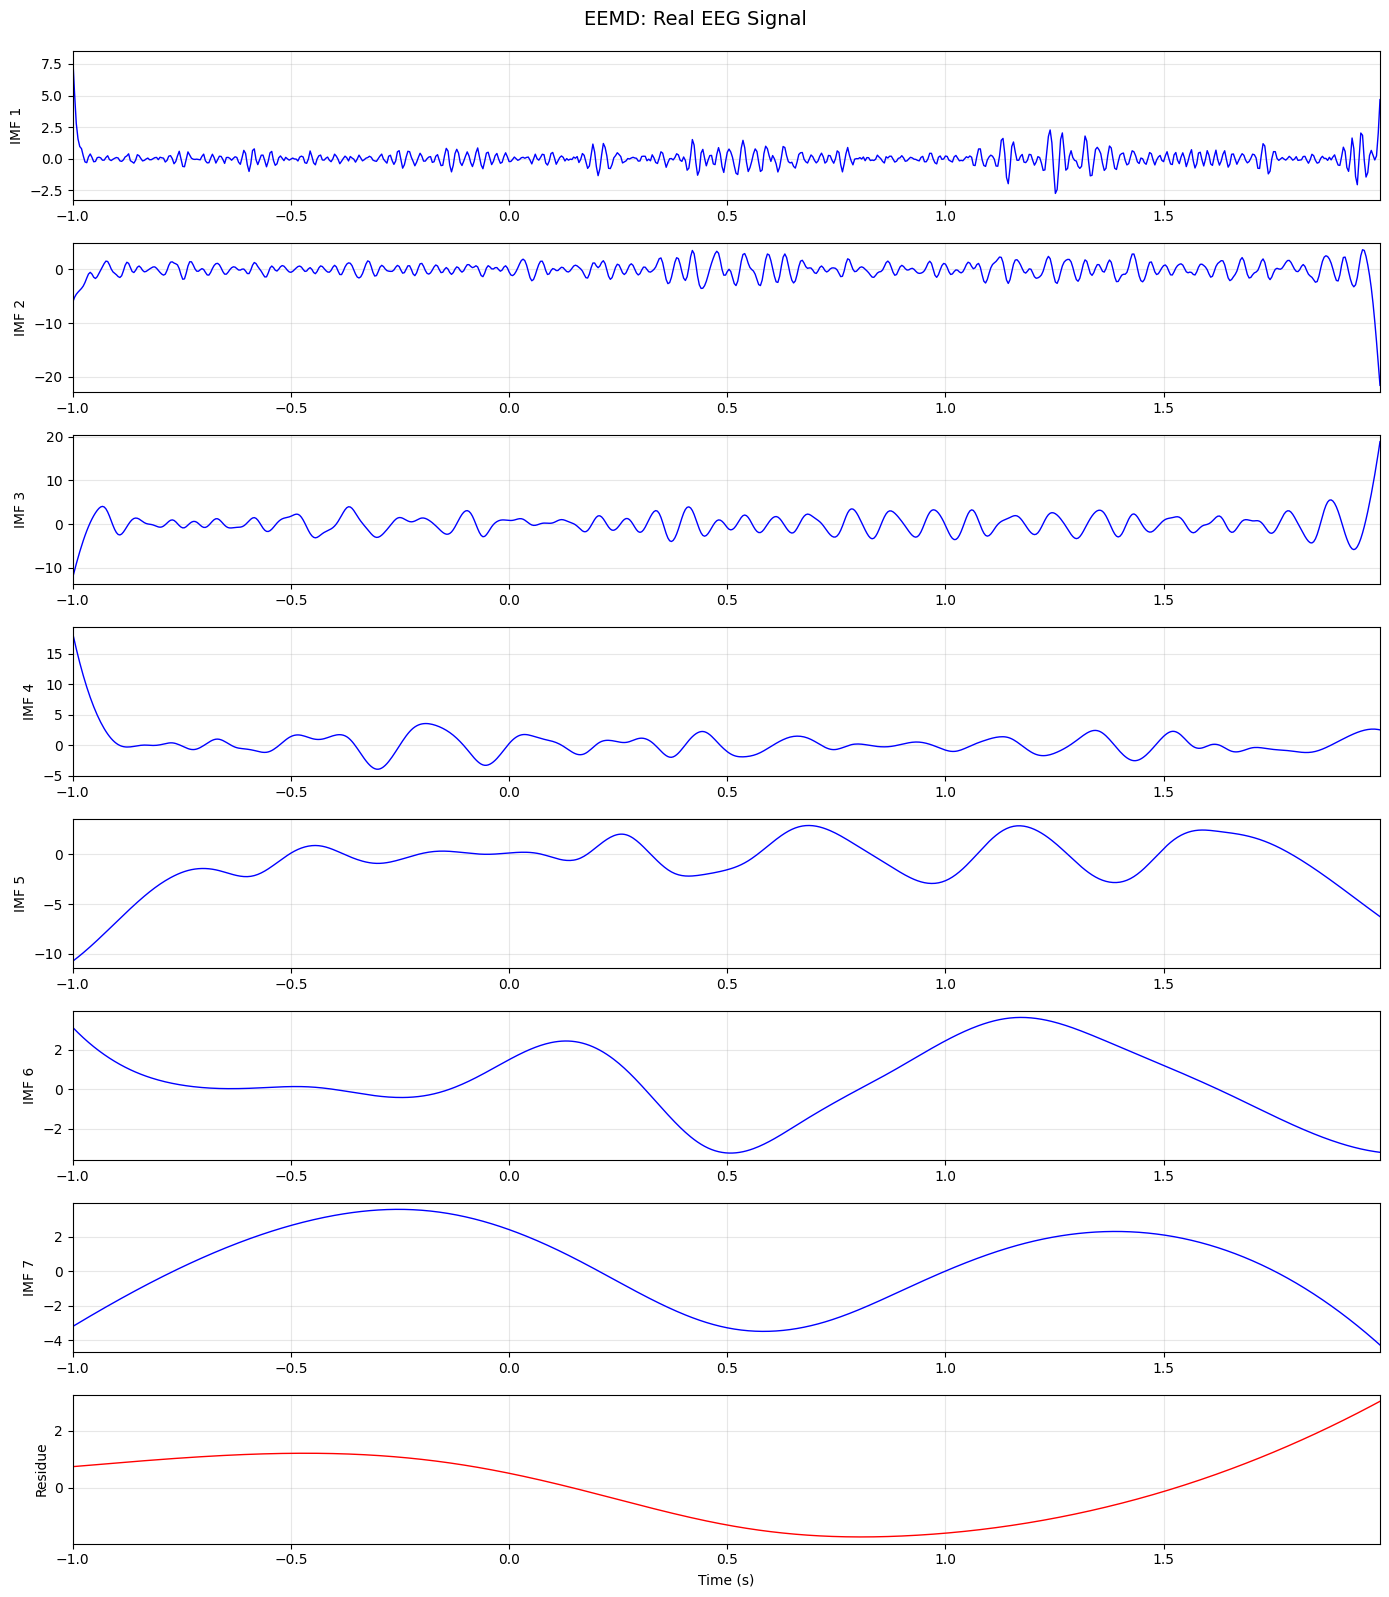

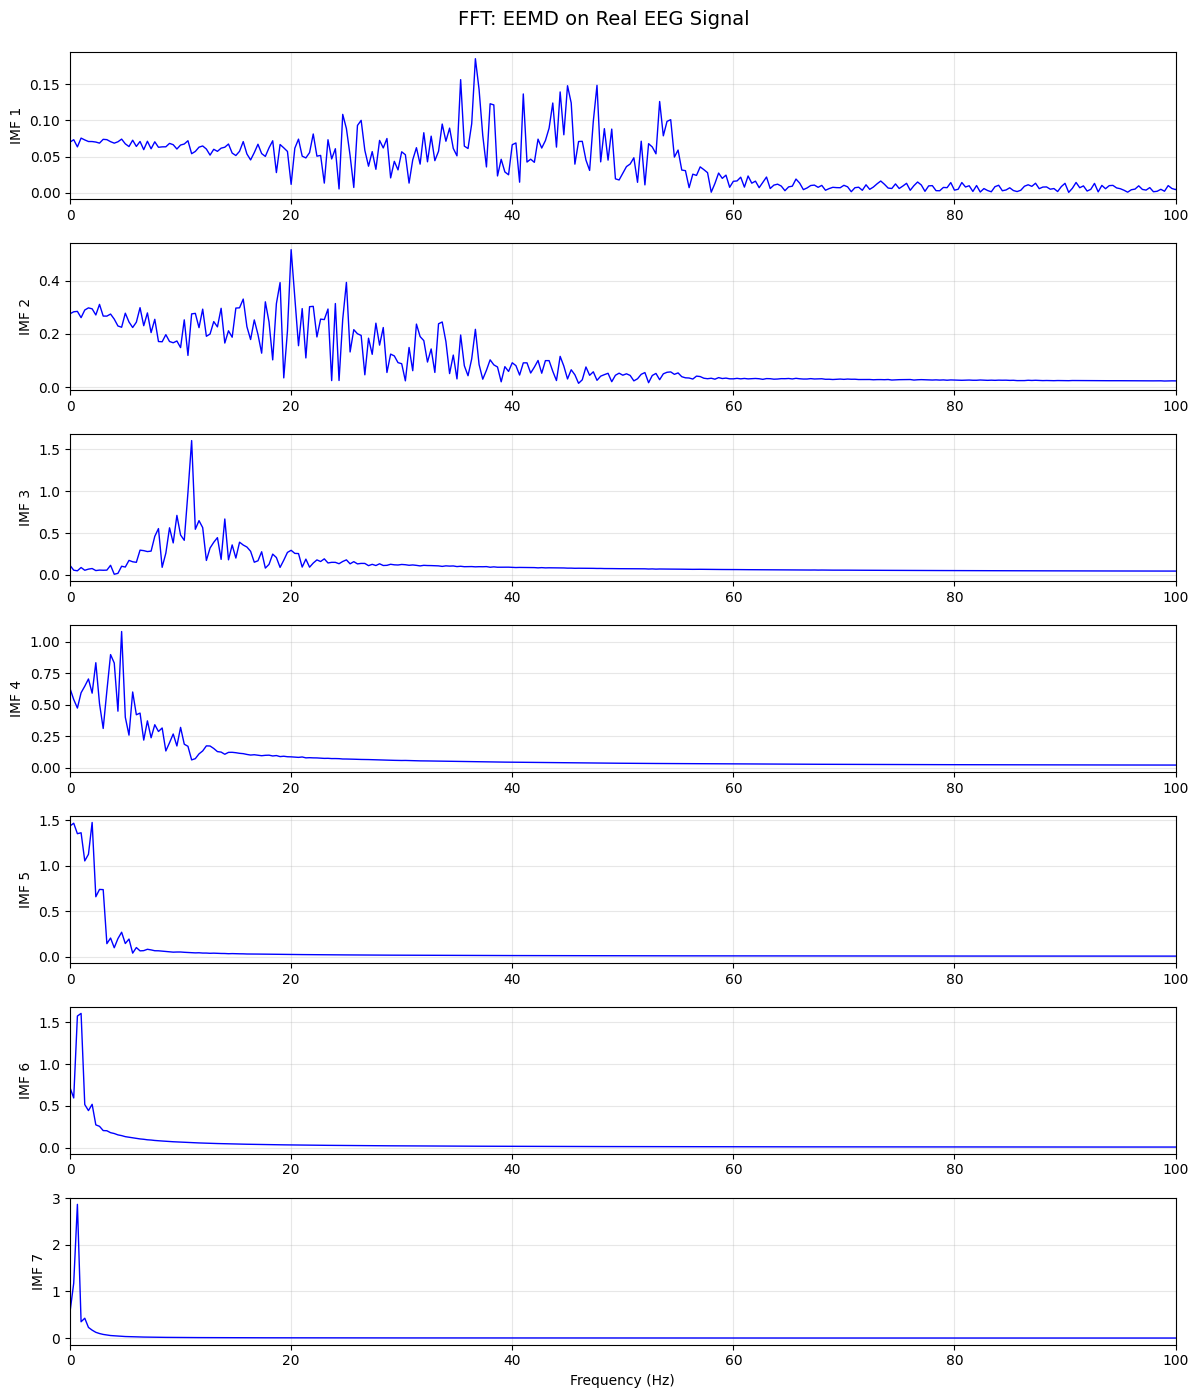

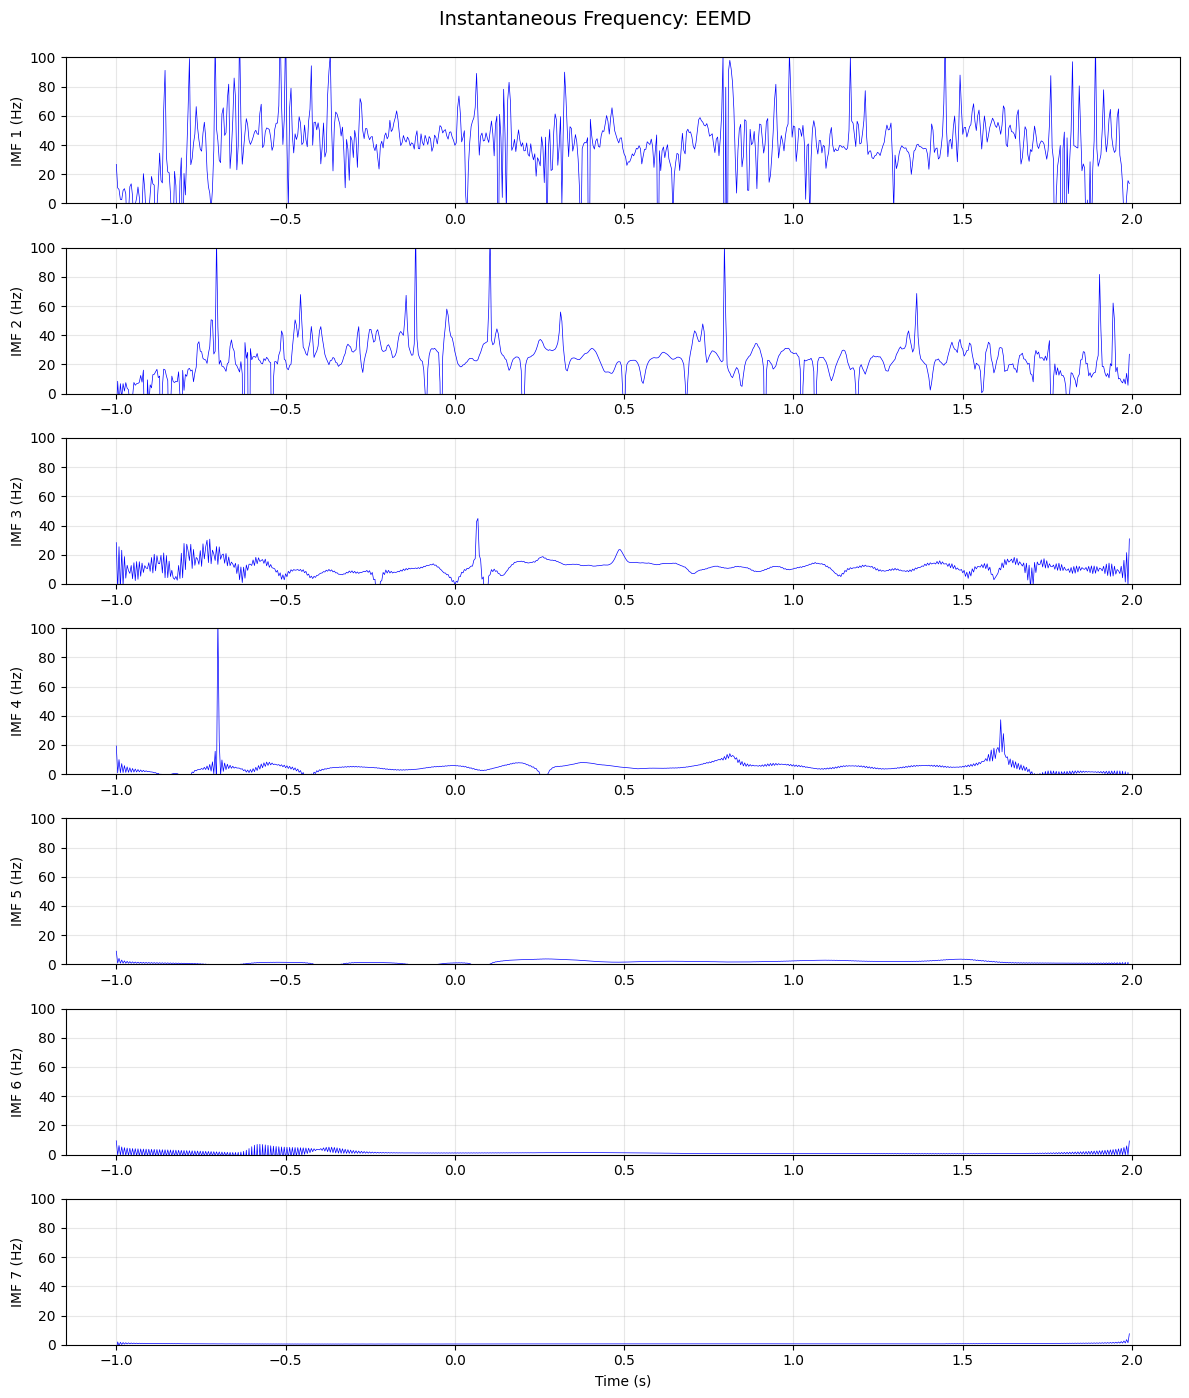

In [91]:
# Run EEMD on the real EEG signal
# Using 100 ensembles with noise_std=0.2 (standard settings)
imfs_eemd, residue_eemd = eemd(signal, time_vector, 
                                n_ensembles=100, 
                                noise_std=0.2,
                                max_sifts=10,
                                spline_type='cubic',
                                use_default_stopping=False,
                                random_seed=42,
                                verbose=True)

# Plot EEMD results
plot_imfs(imfs_eemd, residue_eemd, time_vector, "EEMD: Real EEG Signal")
plot_imf_ffts(imfs_eemd, sr, "FFT: EEMD on Real EEG Signal")
plot_instantaneous_frequencies(imfs_eemd, time_vector, sr, "Instantaneous Frequency: EEMD")